In [ ]:
!pip install -q xgboost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [ ]:
DATA_PATH = Path(
    "/content/primary_model_dataset_prepared (1).csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (191, 52)


,respondent_id,language,submitted_at,age,gender,marital_status,household_size,education_level,field_of_study,time_since_studies,province,digital_access,languages_read_write,english_communication,digital_confidence,internet_use_frequency,formal_training,training_type,training_field,training_duration,training_relevance,reason_no_training,analytical_thinking,resilience_flexibility_agility,leadership_social_influence,creative_thinking,motivation_self_awareness,technological_literacy,empathy_active_listening,curiosity_lifelong_learning,talent_management,service_orientation,employment_status,time_to_first_job,current_work_type,work_education_relevance,employment_satisfaction,job_search_duration,recent_job_search_action,job_search_methods,employment_barrier,available_within_two_weeks,reason_not_looking,intend_seek_after_studies,workforce_preparedness,is_current_schema,employment_status_canonical,recent_job_search_action_canonical,available_within_two_weeks_canonical,labour_market_group,eligible_primary_model,employment_outcome
0,13FtTDlmW2WGWDny4fn0,Tamil,2026-08-14 05:57:29.148000+00:00,28,Female,Never married,5,GCE O-Level,Arts / Humanities / Social Sciences,More than 12 months,Central,Limited access,ஆங்கிலம் | தமிழ் | சிங்களம்,4,3,அடிக்கடி,Yes,Apprenticeship / Technical training,Beauty / Personal Care,More than 1 year,Slightly relevant,NaN,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,வேலை செய்பவர் / சுயதொழில் செய்பவர் / வணிக உரிம...,3–6 மாதங்கள்,தனிப்பட்ட ஒப்பந்தப் பணி (Freelancing) / பணியடி...,மிகவும் தொடர்புடையது,திருப்தி,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,employed,NaN,NaN,EMPLOYED,True,1
1,15UI5kXIjGVQ6NSrvRvL,Tamil,2026-08-13 12:56:50.438000+00:00,25,Female,Never married,3,Certificate / Vocational Training,Vocational Trades,6-12 months,Uva,Limited access,சிங்களம் | தமிழ் | ஆங்கிலம்,3,4,அடிக்கடி,Yes,NVQ,Agriculture,6-12 months,Very relevant,NaN,5.0,4.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,வேலையில்லாமல் இருப்பதுடன் தீவிரமாக வேலை தேடிக்...,NaN,NaN,NaN,NaN,3–6 மாதங்கள்,ஆம்,அரசாங்க வேலைகளுக்கு விண்ணப்பித்தேன் | இணைய வேல...,போக்குவரத்து / இருப்பிடச் சிரமங்கள்,NaN,NaN,NaN,NaN,True,active_unemployed,yes,NaN,ACTIVE_UNEMPLOYED_RECENT_SEARCH,True,0
2,17eZ8UNULeiHGtsq935F,Tamil,2026-08-13 10:50:44.698000+00:00,25,Female,Never married,6,Diploma / HND,Arts / Humanities / Social Sciences,More than 12 months,Uva,Good,தமிழ் | ஆங்கிலம் | சிங்களம்,4,4,அடிக்கடி,Yes,Diploma,Other,6-12 months,Highly relevant,NaN,4.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,வேலையில்லாமல் இருப்பதுடன் தீவிரமாக வேலை தேடிக்...,NaN,NaN,NaN,NaN,12 மாதங்களுக்கும் அதிகமாக,ஆம்,இணைய வேலைவாய்ப்புத் தளங்கள் மூலம் விண்ணப்பித்த...,போக்குவரத்து / இருப்பிடச் சிரமங்கள்,NaN,NaN,NaN,NaN,True,active_unemployed,yes,NaN,ACTIVE_UNEMPLOYED_RECENT_SEARCH,True,0
3,1OGIEgjOI57YuSdYBlEE,Sinhala,2026-08-14 12:46:12.104000+00:00,20,Female,Never married,4,GCE A-Level,IT / Computer Science,6-12 months,Southern,Excellent,සිංහල,3,5,බොහෝ විට,No,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING,මට එය අවශ්‍ය වී නැත,3.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,4.0,4.0,රැකියාවක නියුක්ත / ස්වයං රැකියාවක නියුක්ත / ව්...,මාස 3කට අඩු,අර්ධ කාලීන රැකියාව,අතිශයින් සම්බන්ධයි,ඉතා තෘප්තිමත්ය,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,employed,NaN,NaN,EMPLOYED,True,1
4,1USi3aGfkYsghlKahUMF,Tamil,2026-08-14 16:06:57.724000+00:00,21,Male,Never married,2,Certificate / Vocational Training,Engineering / Technology,More than 12 months,Northern,Good,தமிழ் | ஆங்கிலம்,4,5,அடிக்கடி,Yes,NVQ,Information Technology,6-12 months,Very relevant,NaN,4.0,3.0,4.0,4.0,4.0,5.0,4.0,5.0,4.0,5.0,வேலையில்லாமல் இருப்பதுடன் தீவிரமாக வேலை தேடிக்...,NaN,NaN,NaN,NaN,3 மாதங்களுக்கும் குறைவாக,ஆம்,சமூக ஊடகங்கள் / தொழில்முறை வலையமைப்புகளைப் பயன...,வேலை அனுபவம் இல்லாமை,NaN,NaN,NaN,NaN,True,active_unemployed,yes,NaN,ACTIVE_UNEMPLOYED_RECENT_SEARCH,True,0


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/primary_model_dataset_prepared (1).csv"
)

print("Province counts:")
print(
    df["province"]
    .value_counts(dropna=False)
    .sort_index()
)

Province counts:
province
Central          84
Eastern          20
North Western     3
Northern         23
Sabaragamuwa      3
Southern          5
Uva              31
Western          22
Name: count, dtype: int64


In [ ]:
print("Respondents:", len(df))

print("\nTarget distribution:")
print(
    df["employment_outcome"]
    .value_counts()
    .sort_index()
)

print("\nMissing target:")
print(df["employment_outcome"].isna().sum())

print("\nDuplicate respondent IDs:")
print(df["respondent_id"].duplicated().sum())

Respondents: 191

Target distribution:
employment_outcome
0    101
1     90
Name: count, dtype: int64

Missing target:
0

Duplicate respondent IDs:
0


In [ ]:
MODEL_A_FEATURES = [
    "analytical_thinking",
    "resilience_flexibility_agility",
    "leadership_social_influence",
    "creative_thinking",
    "motivation_self_awareness",
    "technological_literacy",
    "empathy_active_listening",
    "curiosity_lifelong_learning",
    "talent_management",
    "service_orientation",
]

print("Model A feature count:", len(MODEL_A_FEATURES))

for feature in MODEL_A_FEATURES:
    print("-", feature)

Model A feature count: 10
- analytical_thinking
- resilience_flexibility_agility
- leadership_social_influence
- creative_thinking
- motivation_self_awareness
- technological_literacy
- empathy_active_listening
- curiosity_lifelong_learning
- talent_management
- service_orientation


In [ ]:
MODEL_B_ADDITIONAL_FEATURES = [
    # Demographic
    "age",
    "gender",
    "marital_status",
    "household_size",

    # Education / human capital
    "education_level",
    "field_of_study",
    "time_since_studies",

    # Structural / contextual
    "province",
    "digital_access",
    "english_communication",
    "digital_confidence",

    # Training
    "formal_training",
    "training_type",
    "training_field",
    "training_duration",
    "training_relevance",
]

MODEL_B_FEATURES = (
    MODEL_A_FEATURES
    + MODEL_B_ADDITIONAL_FEATURES
)

print("Model B feature count:", len(MODEL_B_FEATURES))

for feature in MODEL_B_FEATURES:
    print("-", feature)

Model B feature count: 26
- analytical_thinking
- resilience_flexibility_agility
- leadership_social_influence
- creative_thinking
- motivation_self_awareness
- technological_literacy
- empathy_active_listening
- curiosity_lifelong_learning
- talent_management
- service_orientation
- age
- gender
- marital_status
- household_size
- education_level
- field_of_study
- time_since_studies
- province
- digital_access
- english_communication
- digital_confidence
- formal_training
- training_type
- training_field
- training_duration
- training_relevance


In [ ]:
X_A = df[MODEL_A_FEATURES].copy()
X_B = df[MODEL_B_FEATURES].copy()

y = df["employment_outcome"].astype(int).copy()

print("X_A:", X_A.shape)
print("X_B:", X_B.shape)
print("y:", y.shape)

X_A: (191, 10)
X_B: (191, 26)
y: (191,)


In [ ]:
all_indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training respondents:", len(train_idx))
print("Test respondents:", len(test_idx))

Training respondents: 152
Test respondents: 39


In [ ]:
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("TRAIN distribution")
print(y_train.value_counts())
print()
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTEST distribution")
print(y_test.value_counts())
print()
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRAIN distribution
employment_outcome
0    80
1    72
Name: count, dtype: int64

employment_outcome
0    52.63
1    47.37
Name: proportion, dtype: float64

TEST distribution
employment_outcome
0    21
1    18
Name: count, dtype: int64

employment_outcome
0    53.85
1    46.15
Name: proportion, dtype: float64


In [ ]:
X_A_train = X_A.iloc[train_idx].copy()
X_A_test  = X_A.iloc[test_idx].copy()

X_B_train = X_B.iloc[train_idx].copy()
X_B_test  = X_B.iloc[test_idx].copy()

print("Model A train:", X_A_train.shape)
print("Model A test:", X_A_test.shape)

print("Model B train:", X_B_train.shape)
print("Model B test:", X_B_test.shape)

Model A train: (152, 10)
Model A test: (39, 10)
Model B train: (152, 26)
Model B test: (39, 26)


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_splits = list(
    cv.split(
        np.zeros(len(y_train)),
        y_train
    )
)

print("Number of CV folds:", len(cv_splits))

for i, (fold_train, fold_valid) in enumerate(
    cv_splits,
    start=1
):
    print(
        f"Fold {i}: "
        f"train={len(fold_train)}, "
        f"validation={len(fold_valid)}"
    )

Number of CV folds: 5
Fold 1: train=121, validation=31
Fold 2: train=121, validation=31
Fold 3: train=122, validation=30
Fold 4: train=122, validation=30
Fold 5: train=122, validation=30


In [ ]:
MODEL_A_NUMERIC_FEATURES = MODEL_A_FEATURES.copy()

model_a_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            MODEL_A_NUMERIC_FEATURES
        )
    ],
    remainder="drop"
)

print("Model A preprocessor created.")

Model A preprocessor created.


In [ ]:
MODEL_B_NUMERIC_FEATURES = [
    # Skills
    "analytical_thinking",
    "resilience_flexibility_agility",
    "leadership_social_influence",
    "creative_thinking",
    "motivation_self_awareness",
    "technological_literacy",
    "empathy_active_listening",
    "curiosity_lifelong_learning",
    "talent_management",
    "service_orientation",

    # Other numeric features
    "age",
    "household_size",
    "english_communication",
    "digital_confidence",
]


MODEL_B_CATEGORICAL_FEATURES = [
    "gender",
    "marital_status",
    "education_level",
    "field_of_study",
    "time_since_studies",
    "province",
    "digital_access",

    "formal_training",
    "training_type",
    "training_field",
    "training_duration",
    "training_relevance",
]

print(
    "Numeric:",
    len(MODEL_B_NUMERIC_FEATURES)
)

print(
    "Categorical:",
    len(MODEL_B_CATEGORICAL_FEATURES)
)

print(
    "Total:",
    len(MODEL_B_NUMERIC_FEATURES)
    + len(MODEL_B_CATEGORICAL_FEATURES)
)

Numeric: 14
Categorical: 12
Total: 26


In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


model_b_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            MODEL_B_NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_pipeline,
            MODEL_B_CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)

print("Model B preprocessor created.")

Model B preprocessor created.


In [ ]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

print(lr_model)

LogisticRegression(max_iter=2000, random_state=42)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(rf_model)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [ ]:
pipelines = {
    "A_LogisticRegression": Pipeline([
        ("preprocessor", model_a_preprocessor),
        ("classifier", lr_model)
    ]),

    "A_RandomForest": Pipeline([
        ("preprocessor", model_a_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]),

    "A_XGBoost": Pipeline([
        ("preprocessor", model_a_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]),

    "B_LogisticRegression": Pipeline([
        ("preprocessor", model_b_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "B_RandomForest": Pipeline([
        ("preprocessor", model_b_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]),

    "B_XGBoost": Pipeline([
        ("preprocessor", model_b_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])
}

print("Number of pipelines:", len(pipelines))
print()

for name in pipelines:
    print(name)

Number of pipelines: 6

A_LogisticRegression
A_RandomForest
A_XGBoost
B_LogisticRegression
B_RandomForest
B_XGBoost


In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [ ]:
cv_results = []

for name, pipeline in pipelines.items():

    print("Running:", name)

    # Select appropriate X
    if name.startswith("A_"):
        X_train_current = X_A_train
    else:
        X_train_current = X_B_train

    result = cross_validate(
        estimator=pipeline,
        X=X_train_current,
        y=y_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,

        "accuracy_mean":
            result["test_accuracy"].mean(),

        "accuracy_std":
            result["test_accuracy"].std(),

        "precision_mean":
            result["test_precision"].mean(),

        "precision_std":
            result["test_precision"].std(),

        "recall_mean":
            result["test_recall"].mean(),

        "recall_std":
            result["test_recall"].std(),

        "f1_mean":
            result["test_f1"].mean(),

        "f1_std":
            result["test_f1"].std(),

        "roc_auc_mean":
            result["test_roc_auc"].mean(),

        "roc_auc_std":
            result["test_roc_auc"].std(),
    })

Running: A_LogisticRegression
Running: A_RandomForest
Running: A_XGBoost
Running: B_LogisticRegression
Running: B_RandomForest
Running: B_XGBoost


In [ ]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = (
    cv_results_df
    .sort_values(
        by="roc_auc_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cv_results_df.round(4)
)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,B_RandomForest,0.8166,0.0617,0.7979,0.0811,0.8343,0.0280,0.8143,0.0523,0.9143,0.0236
1,B_XGBoost,0.7576,0.0699,0.7335,0.0707,0.7790,0.0768,0.7537,0.0647,0.8285,0.0487
2,A_RandomForest,0.7043,0.0323,0.6799,0.0458,0.7343,0.0731,0.7015,0.0179,0.8185,0.0281
3,B_LogisticRegression,0.7176,0.0624,0.7023,0.0764,0.7219,0.1154,0.7057,0.0708,0.7838,0.0612
4,A_XGBoost,0.7108,0.0212,0.6750,0.0318,0.7629,0.0581,0.7138,0.0145,0.7526,0.0436
5,A_LogisticRegression,0.6387,0.0722,0.6556,0.1255,0.5819,0.0803,0.6061,0.0510,0.6478,0.0630


In [ ]:
fitted_models = {}

for name, pipeline in pipelines.items():

    print("Fitting:", name)

    if name.startswith("A_"):
        X_train_current = X_A_train
    else:
        X_train_current = X_B_train

    pipeline.fit(
        X_train_current,
        y_train
    )

    fitted_models[name] = pipeline

print("\nAll six models fitted.")

Fitting: A_LogisticRegression
Fitting: A_RandomForest
Fitting: A_XGBoost
Fitting: B_LogisticRegression
Fitting: B_RandomForest
Fitting: B_XGBoost

All six models fitted.


In [ ]:
def evaluate_test_model(
    name,
    model,
    X_test,
    y_test
):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "model": name,

        "accuracy":
            accuracy_score(y_test, y_pred),

        "precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                y_prob
            )
    }

In [ ]:
test_results = []

for name, model in fitted_models.items():

    if name.startswith("A_"):
        X_test_current = X_A_test
    else:
        X_test_current = X_B_test

    metrics = evaluate_test_model(
        name,
        model,
        X_test_current,
        y_test
    )

    test_results.append(metrics)

In [ ]:
test_results_df = pd.DataFrame(
    test_results
)

test_results_df = (
    test_results_df
    .sort_values(
        by="roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    test_results_df.round(4)
)

,model,accuracy,precision,recall,f1,roc_auc
0,B_RandomForest,0.8462,0.9286,0.7222,0.8125,0.9286
1,B_XGBoost,0.7692,0.7647,0.7222,0.7429,0.8995
2,A_RandomForest,0.7949,0.7500,0.8333,0.7895,0.8413
3,B_LogisticRegression,0.6923,0.6667,0.6667,0.6667,0.8148
4,A_XGBoost,0.7692,0.7143,0.8333,0.7692,0.7857
5,A_LogisticRegression,0.4615,0.4000,0.3333,0.3636,0.4206


In [ ]:
for name, model in fitted_models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    if name.startswith("A_"):
        X_test_current = X_A_test
    else:
        X_test_current = X_B_test

    y_pred = model.predict(
        X_test_current
    )

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Active unemployed recent-search",
                "Employed"
            ],
            zero_division=0
        )
    )



A_LogisticRegression
                                 precision    recall  f1-score   support

Active unemployed recent-search       0.50      0.57      0.53        21
                       Employed       0.40      0.33      0.36        18

                       accuracy                           0.46        39
                      macro avg       0.45      0.45      0.45        39
                   weighted avg       0.45      0.46      0.46        39



A_RandomForest
                                 precision    recall  f1-score   support

Active unemployed recent-search       0.84      0.76      0.80        21
                       Employed       0.75      0.83      0.79        18

                       accuracy                           0.79        39
                      macro avg       0.80      0.80      0.79        39
                   weighted avg       0.80      0.79      0.80        39



A_XGBoost
                                 precision    recall  f1-score   s

In [ ]:
confusion_matrices = {}

for name, model in fitted_models.items():

    if name.startswith("A_"):
        X_test_current = X_A_test
    else:
        X_test_current = X_B_test

    y_pred = model.predict(
        X_test_current
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_matrices[name] = cm

    print("\n", name)
    print(cm)


 A_LogisticRegression
[[12  9]
 [12  6]]

 A_RandomForest
[[16  5]
 [ 3 15]]

 A_XGBoost
[[15  6]
 [ 3 15]]

 B_LogisticRegression
[[15  6]
 [ 6 12]]

 B_RandomForest
[[20  1]
 [ 5 13]]

 B_XGBoost
[[17  4]
 [ 5 13]]


In [ ]:
pairwise_rows = []

algorithm_pairs = [
    (
        "Logistic Regression",
        "A_LogisticRegression",
        "B_LogisticRegression"
    ),
    (
        "Random Forest",
        "A_RandomForest",
        "B_RandomForest"
    ),
    (
        "XGBoost",
        "A_XGBoost",
        "B_XGBoost"
    )
]

for algorithm, model_a, model_b in algorithm_pairs:

    a = test_results_df.loc[
        test_results_df["model"] == model_a
    ].iloc[0]

    b = test_results_df.loc[
        test_results_df["model"] == model_b
    ].iloc[0]

    pairwise_rows.append({
        "algorithm": algorithm,

        "A_accuracy": a["accuracy"],
        "B_accuracy": b["accuracy"],
        "delta_accuracy":
            b["accuracy"] - a["accuracy"],

        "A_f1": a["f1"],
        "B_f1": b["f1"],
        "delta_f1":
            b["f1"] - a["f1"],

        "A_roc_auc": a["roc_auc"],
        "B_roc_auc": b["roc_auc"],
        "delta_roc_auc":
            b["roc_auc"] - a["roc_auc"],
    })

pairwise_comparison = pd.DataFrame(
    pairwise_rows
)

display(
    pairwise_comparison.round(4)
)

,algorithm,A_accuracy,B_accuracy,delta_accuracy,A_f1,B_f1,delta_f1,A_roc_auc,B_roc_auc,delta_roc_auc
0,Logistic Regression,0.4615,0.6923,0.2308,0.3636,0.6667,0.3030,0.4206,0.8148,0.3942
1,Random Forest,0.7949,0.8462,0.0513,0.7895,0.8125,0.0230,0.8413,0.9286,0.0873
2,XGBoost,0.7692,0.7692,0.0000,0.7692,0.7429,-0.0264,0.7857,0.8995,0.1138


In [ ]:
cv_pairwise_rows = []

for algorithm, model_a, model_b in algorithm_pairs:

    a = cv_results_df.loc[
        cv_results_df["model"] == model_a
    ].iloc[0]

    b = cv_results_df.loc[
        cv_results_df["model"] == model_b
    ].iloc[0]

    cv_pairwise_rows.append({
        "algorithm": algorithm,

        "A_cv_f1":
            a["f1_mean"],

        "B_cv_f1":
            b["f1_mean"],

        "delta_cv_f1":
            b["f1_mean"]
            - a["f1_mean"],

        "A_cv_roc_auc":
            a["roc_auc_mean"],

        "B_cv_roc_auc":
            b["roc_auc_mean"],

        "delta_cv_roc_auc":
            b["roc_auc_mean"]
            - a["roc_auc_mean"],
    })

cv_pairwise_comparison = pd.DataFrame(
    cv_pairwise_rows
)

display(
    cv_pairwise_comparison.round(4)
)

,algorithm,A_cv_f1,B_cv_f1,delta_cv_f1,A_cv_roc_auc,B_cv_roc_auc,delta_cv_roc_auc
0,Logistic Regression,0.6061,0.7057,0.0996,0.6478,0.7838,0.1360
1,Random Forest,0.7015,0.8143,0.1127,0.8185,0.9143,0.0958
2,XGBoost,0.7138,0.7537,0.0399,0.7526,0.8285,0.0760


In [ ]:
RESULTS_DIR = Path("/content/results")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

cv_results_df.to_csv(
    RESULTS_DIR / "cv_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    RESULTS_DIR / "test_model_comparison.csv",
    index=False
)

pairwise_comparison.to_csv(
    RESULTS_DIR / "model_a_vs_b_test_comparison.csv",
    index=False
)

cv_pairwise_comparison.to_csv(
    RESULTS_DIR / "model_a_vs_b_cv_comparison.csv",
    index=False
)

print("Results saved.")

Results saved.


In [ ]:
split_records = []

for idx in train_idx:
    split_records.append({
        "respondent_id":
            df.iloc[idx]["respondent_id"],
        "split": "train"
    })

for idx in test_idx:
    split_records.append({
        "respondent_id":
            df.iloc[idx]["respondent_id"],
        "split": "test"
    })

split_df = pd.DataFrame(
    split_records
)

split_df.to_csv(
    RESULTS_DIR / "train_test_split_membership.csv",
    index=False
)

display(
    split_df["split"]
    .value_counts()
)

,count
split,
train,152
test,39


In [ ]:
from sklearn.model_selection import cross_val_predict

from sklearn.metrics import (
    balanced_accuracy_score,
    average_precision_score,
    precision_recall_fscore_support
)

In [ ]:
def comprehensive_metrics(y_true, y_pred, y_prob):

    # Per-class precision, recall, F1
    precision_per_class, recall_per_class, f1_per_class, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0
        )
    )

    # PR-AUC / Average Precision for class 1 = employed
    ap_employed = average_precision_score(
        y_true,
        y_prob
    )

    # Reverse target/probability for class 0 = unemployed
    ap_unemployed = average_precision_score(
        1 - np.asarray(y_true),
        1 - np.asarray(y_prob)
    )

    return {
        "accuracy":
            accuracy_score(y_true, y_pred),

        "balanced_accuracy":
            balanced_accuracy_score(y_true, y_pred),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        # Class 0
        "precision_unemployed":
            precision_per_class[0],

        "recall_unemployed":
            recall_per_class[0],

        "f1_unemployed":
            f1_per_class[0],

        # Class 1
        "precision_employed":
            precision_per_class[1],

        "recall_employed":
            recall_per_class[1],

        "f1_employed":
            f1_per_class[1],

        "roc_auc":
            roc_auc_score(y_true, y_prob),

        "pr_auc_employed":
            ap_employed,

        "pr_auc_unemployed":
            ap_unemployed,

        "macro_pr_auc":
            (ap_employed + ap_unemployed) / 2
    }

In [ ]:
oof_results = []

oof_predictions = {}

for name, pipeline in pipelines.items():

    print("Generating OOF predictions:", name)

    if name.startswith("A_"):
        X_current = X_A_train
    else:
        X_current = X_B_train

    # Out-of-fold class predictions
    y_pred_oof = cross_val_predict(
        pipeline,
        X_current,
        y_train,
        cv=cv_splits,
        method="predict",
        n_jobs=-1
    )

    # Out-of-fold probability predictions
    y_prob_oof = cross_val_predict(
        pipeline,
        X_current,
        y_train,
        cv=cv_splits,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    metrics = comprehensive_metrics(
        y_train,
        y_pred_oof,
        y_prob_oof
    )

    metrics["model"] = name

    oof_results.append(metrics)

    oof_predictions[name] = {
        "y_pred": y_pred_oof,
        "y_prob": y_prob_oof
    }

Generating OOF predictions: A_LogisticRegression
Generating OOF predictions: A_RandomForest
Generating OOF predictions: A_XGBoost
Generating OOF predictions: B_LogisticRegression
Generating OOF predictions: B_RandomForest
Generating OOF predictions: B_XGBoost


In [ ]:
oof_results_df = pd.DataFrame(
    oof_results
)

column_order = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",

    "precision_unemployed",
    "recall_unemployed",
    "f1_unemployed",

    "precision_employed",
    "recall_employed",
    "f1_employed",

    "roc_auc",
    "pr_auc_unemployed",
    "pr_auc_employed",
    "macro_pr_auc"
]

oof_results_df = (
    oof_results_df[column_order]
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    oof_results_df.round(4)
)

,model,accuracy,balanced_accuracy,macro_f1,precision_unemployed,recall_unemployed,f1_unemployed,precision_employed,recall_employed,f1_employed,roc_auc,pr_auc_unemployed,pr_auc_employed,macro_pr_auc
0,B_RandomForest,0.8158,0.8167,0.8157,0.8421,0.8000,0.8205,0.7895,0.8333,0.8108,0.9129,0.9196,0.9203,0.9200
1,B_XGBoost,0.7566,0.7576,0.7565,0.7867,0.7375,0.7613,0.7273,0.7778,0.7517,0.8339,0.8612,0.8081,0.8347
2,A_RandomForest,0.7039,0.7056,0.7039,0.7397,0.6750,0.7059,0.6709,0.7361,0.7020,0.8063,0.8301,0.7859,0.8080
3,B_LogisticRegression,0.7171,0.7174,0.7168,0.7403,0.7125,0.7261,0.6933,0.7222,0.7075,0.7903,0.8095,0.7533,0.7814
4,A_XGBoost,0.7105,0.7132,0.7105,0.7571,0.6625,0.7067,0.6707,0.7639,0.7143,0.7472,0.7449,0.6744,0.7096
5,A_LogisticRegression,0.6382,0.6354,0.6355,0.6471,0.6875,0.6667,0.6269,0.5833,0.6043,0.6396,0.6063,0.6197,0.6130


In [ ]:
detailed_test_results = []

for name, model in fitted_models.items():

    if name.startswith("A_"):
        X_current = X_A_test
    else:
        X_current = X_B_test

    y_pred = model.predict(
        X_current
    )

    y_prob = model.predict_proba(
        X_current
    )[:, 1]

    metrics = comprehensive_metrics(
        y_test,
        y_pred,
        y_prob
    )

    metrics["model"] = name

    detailed_test_results.append(
        metrics
    )


detailed_test_results_df = pd.DataFrame(
    detailed_test_results
)

detailed_test_results_df = (
    detailed_test_results_df[column_order]
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    detailed_test_results_df.round(4)
)

,model,accuracy,balanced_accuracy,macro_f1,precision_unemployed,recall_unemployed,f1_unemployed,precision_employed,recall_employed,f1_employed,roc_auc,pr_auc_unemployed,pr_auc_employed,macro_pr_auc
0,B_RandomForest,0.8462,0.8373,0.8410,0.8000,0.9524,0.8696,0.9286,0.7222,0.8125,0.9286,0.9389,0.9293,0.9341
1,B_XGBoost,0.7692,0.7659,0.7668,0.7727,0.8095,0.7907,0.7647,0.7222,0.7429,0.8995,0.8921,0.9143,0.9032
2,A_RandomForest,0.7949,0.7976,0.7947,0.8421,0.7619,0.8000,0.7500,0.8333,0.7895,0.8413,0.8900,0.7961,0.8431
3,B_LogisticRegression,0.6923,0.6905,0.6905,0.7143,0.7143,0.7143,0.6667,0.6667,0.6667,0.8148,0.8334,0.8324,0.8329
4,A_XGBoost,0.7692,0.7738,0.7692,0.8333,0.7143,0.7692,0.7143,0.8333,0.7692,0.7857,0.8519,0.6890,0.7704
5,A_LogisticRegression,0.4615,0.4524,0.4485,0.5000,0.5714,0.5333,0.4000,0.3333,0.3636,0.4206,0.5221,0.4501,0.4861


In [ ]:
oof_pairwise_rows = []

for algorithm, model_a, model_b in algorithm_pairs:

    a = oof_results_df.loc[
        oof_results_df["model"] == model_a
    ].iloc[0]

    b = oof_results_df.loc[
        oof_results_df["model"] == model_b
    ].iloc[0]

    oof_pairwise_rows.append({

        "algorithm": algorithm,

        "A_balanced_accuracy":
            a["balanced_accuracy"],

        "B_balanced_accuracy":
            b["balanced_accuracy"],

        "delta_balanced_accuracy":
            b["balanced_accuracy"]
            - a["balanced_accuracy"],


        "A_macro_f1":
            a["macro_f1"],

        "B_macro_f1":
            b["macro_f1"],

        "delta_macro_f1":
            b["macro_f1"]
            - a["macro_f1"],


        "A_roc_auc":
            a["roc_auc"],

        "B_roc_auc":
            b["roc_auc"],

        "delta_roc_auc":
            b["roc_auc"]
            - a["roc_auc"],


        "A_macro_pr_auc":
            a["macro_pr_auc"],

        "B_macro_pr_auc":
            b["macro_pr_auc"],

        "delta_macro_pr_auc":
            b["macro_pr_auc"]
            - a["macro_pr_auc"]
    })


oof_pairwise_comparison = pd.DataFrame(
    oof_pairwise_rows
)

display(
    oof_pairwise_comparison.round(4)
)

,algorithm,A_balanced_accuracy,B_balanced_accuracy,delta_balanced_accuracy,A_macro_f1,B_macro_f1,delta_macro_f1,A_roc_auc,B_roc_auc,delta_roc_auc,A_macro_pr_auc,B_macro_pr_auc,delta_macro_pr_auc
0,Logistic Regression,0.6354,0.7174,0.0819,0.6355,0.7168,0.0813,0.6396,0.7903,0.1507,0.6130,0.7814,0.1684
1,Random Forest,0.7056,0.8167,0.1111,0.7039,0.8157,0.1117,0.8063,0.9129,0.1067,0.8080,0.9200,0.1119
2,XGBoost,0.7132,0.7576,0.0444,0.7105,0.7565,0.0460,0.7472,0.8339,0.0866,0.7096,0.8347,0.1250


In [ ]:
def bootstrap_metric_ci(
    y_true,
    y_pred,
    y_prob,
    metric_name,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n = len(y_true)

    values = []

    for _ in range(n_bootstrap):

        idx = rng.choice(
            np.arange(n),
            size=n,
            replace=True
        )

        y_b = y_true[idx]
        pred_b = y_pred[idx]
        prob_b = y_prob[idx]

        # ROC-AUC cannot be calculated
        # if bootstrap sample has only one class.
        if len(np.unique(y_b)) < 2:
            continue

        if metric_name == "roc_auc":

            value = roc_auc_score(
                y_b,
                prob_b
            )

        elif metric_name == "balanced_accuracy":

            value = balanced_accuracy_score(
                y_b,
                pred_b
            )

        elif metric_name == "macro_f1":

            value = f1_score(
                y_b,
                pred_b,
                average="macro",
                zero_division=0
            )

        else:
            raise ValueError(
                "Unsupported metric"
            )

        values.append(value)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return lower, upper

In [ ]:
bootstrap_results = []

for name, model in fitted_models.items():

    print("Bootstrapping:", name)

    if name.startswith("A_"):
        X_current = X_A_test
    else:
        X_current = X_B_test

    y_pred = model.predict(
        X_current
    )

    y_prob = model.predict_proba(
        X_current
    )[:, 1]

    point_roc = roc_auc_score(
        y_test,
        y_prob
    )

    roc_low, roc_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "roc_auc"
    )


    point_bacc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    bacc_low, bacc_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "balanced_accuracy"
    )


    point_macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_low, f1_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "macro_f1"
    )


    bootstrap_results.append({

        "model": name,

        "roc_auc":
            point_roc,

        "roc_auc_ci_low":
            roc_low,

        "roc_auc_ci_high":
            roc_high,

        "balanced_accuracy":
            point_bacc,

        "balanced_accuracy_ci_low":
            bacc_low,

        "balanced_accuracy_ci_high":
            bacc_high,

        "macro_f1":
            point_macro_f1,

        "macro_f1_ci_low":
            f1_low,

        "macro_f1_ci_high":
            f1_high
    })


bootstrap_results_df = pd.DataFrame(
    bootstrap_results
)

bootstrap_results_df = (
    bootstrap_results_df
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    bootstrap_results_df.round(4)
)

Bootstrapping: A_LogisticRegression
Bootstrapping: A_RandomForest
Bootstrapping: A_XGBoost
Bootstrapping: B_LogisticRegression
Bootstrapping: B_RandomForest
Bootstrapping: B_XGBoost


,model,roc_auc,roc_auc_ci_low,roc_auc_ci_high,balanced_accuracy,balanced_accuracy_ci_low,balanced_accuracy_ci_high,macro_f1,macro_f1_ci_low,macro_f1_ci_high
0,B_RandomForest,0.9286,0.8385,0.9895,0.8373,0.7126,0.9444,0.8410,0.7111,0.9470
1,B_XGBoost,0.8995,0.7710,0.9864,0.7659,0.6217,0.8929,0.7668,0.6144,0.8917
2,A_RandomForest,0.8413,0.6978,0.9458,0.7976,0.6645,0.9167,0.7947,0.6586,0.8974
3,B_LogisticRegression,0.8148,0.6614,0.9392,0.6905,0.5375,0.8375,0.6905,0.5334,0.8375
4,A_XGBoost,0.7857,0.6168,0.9233,0.7738,0.6358,0.8968,0.7692,0.6289,0.8940
5,A_LogisticRegression,0.4206,0.2416,0.6112,0.4524,0.3016,0.6105,0.4485,0.2909,0.6061


In [ ]:
fold_results = []

for name, pipeline in pipelines.items():

    print("Fold evaluation:", name)

    if name.startswith("A_"):
        X_current = X_A_train
    else:
        X_current = X_B_train

    result = cross_validate(
        estimator=pipeline,
        X=X_current,
        y=y_train,
        cv=cv_splits,
        scoring={
            "balanced_accuracy":
                "balanced_accuracy",

            "f1_macro":
                "f1_macro",

            "roc_auc":
                "roc_auc"
        },
        return_train_score=False,
        n_jobs=-1
    )

    for fold in range(
        len(cv_splits)
    ):

        fold_results.append({

            "model": name,

            "fold":
                fold + 1,

            "balanced_accuracy":
                result[
                    "test_balanced_accuracy"
                ][fold],

            "macro_f1":
                result[
                    "test_f1_macro"
                ][fold],

            "roc_auc":
                result[
                    "test_roc_auc"
                ][fold]
        })


fold_results_df = pd.DataFrame(
    fold_results
)

display(
    fold_results_df.round(4)
)

Fold evaluation: A_LogisticRegression
Fold evaluation: A_RandomForest
Fold evaluation: A_XGBoost
Fold evaluation: B_LogisticRegression
Fold evaluation: B_RandomForest
Fold evaluation: B_XGBoost


,model,fold,balanced_accuracy,macro_f1,roc_auc
0,A_LogisticRegression,1,0.5542,0.5363,0.5792
1,A_LogisticRegression,2,0.6417,0.6392,0.6375
2,A_LogisticRegression,3,0.7545,0.7532,0.7411
3,A_LogisticRegression,4,0.5938,0.5928,0.5848
4,A_LogisticRegression,5,0.6295,0.6296,0.6964
5,A_RandomForest,1,0.6521,0.6314,0.8083
6,A_RandomForest,2,0.7104,0.7097,0.8333
7,A_RandomForest,3,0.6964,0.6970,0.8214
8,A_RandomForest,4,0.7321,0.7321,0.8571
9,A_RandomForest,5,0.7321,0.7321,0.7723


In [ ]:
paired_fold_rows = []

for algorithm, model_a, model_b in algorithm_pairs:

    a = (
        fold_results_df[
            fold_results_df["model"] == model_a
        ]
        .sort_values("fold")
        .reset_index(drop=True)
    )

    b = (
        fold_results_df[
            fold_results_df["model"] == model_b
        ]
        .sort_values("fold")
        .reset_index(drop=True)
    )

    for i in range(len(a)):

        paired_fold_rows.append({

            "algorithm":
                algorithm,

            "fold":
                int(a.loc[i, "fold"]),

            "delta_balanced_accuracy":
                b.loc[i, "balanced_accuracy"]
                - a.loc[i, "balanced_accuracy"],

            "delta_macro_f1":
                b.loc[i, "macro_f1"]
                - a.loc[i, "macro_f1"],

            "delta_roc_auc":
                b.loc[i, "roc_auc"]
                - a.loc[i, "roc_auc"]
        })


paired_fold_deltas = pd.DataFrame(
    paired_fold_rows
)

display(
    paired_fold_deltas.round(4)
)

,algorithm,fold,delta_balanced_accuracy,delta_macro_f1,delta_roc_auc
0,Logistic Regression,1,0.1292,0.1325,0.2000
1,Logistic Regression,2,0.0333,0.0352,0.0958
2,Logistic Regression,3,0.0759,0.0784,0.1607
3,Logistic Regression,4,0.1429,0.1406,0.1786
4,Logistic Regression,5,0.0312,0.0310,0.0446
5,Random Forest,1,0.0604,0.0771,0.0792
6,Random Forest,2,0.0958,0.0966,0.0583
7,Random Forest,3,0.2009,0.2020,0.1295
8,Random Forest,4,0.1027,0.1010,0.0714
9,Random Forest,5,0.1027,0.1010,0.1406


In [ ]:
paired_summary = (
    paired_fold_deltas
    .groupby("algorithm")
    .agg(
        mean_delta_balanced_accuracy=(
            "delta_balanced_accuracy",
            "mean"
        ),

        std_delta_balanced_accuracy=(
            "delta_balanced_accuracy",
            "std"
        ),

        mean_delta_macro_f1=(
            "delta_macro_f1",
            "mean"
        ),

        std_delta_macro_f1=(
            "delta_macro_f1",
            "std"
        ),

        mean_delta_roc_auc=(
            "delta_roc_auc",
            "mean"
        ),

        std_delta_roc_auc=(
            "delta_roc_auc",
            "std"
        )
    )
    .reset_index()
)

display(
    paired_summary.round(4)
)

,algorithm,mean_delta_balanced_accuracy,std_delta_balanced_accuracy,mean_delta_macro_f1,std_delta_macro_f1,mean_delta_roc_auc,std_delta_roc_auc
0,Logistic Regression,0.0825,0.0522,0.0835,0.0519,0.1360,0.0642
1,Random Forest,0.1125,0.0524,0.1155,0.0493,0.0958,0.0368
2,XGBoost,0.0456,0.0694,0.0477,0.0681,0.0760,0.0647


In [ ]:
oof_results_df.to_csv(
    RESULTS_DIR /
    "oof_comprehensive_metrics.csv",
    index=False
)

detailed_test_results_df.to_csv(
    RESULTS_DIR /
    "test_comprehensive_metrics.csv",
    index=False
)

oof_pairwise_comparison.to_csv(
    RESULTS_DIR /
    "oof_model_a_vs_b_comparison.csv",
    index=False
)

bootstrap_results_df.to_csv(
    RESULTS_DIR /
    "test_bootstrap_confidence_intervals.csv",
    index=False
)

fold_results_df.to_csv(
    RESULTS_DIR /
    "cv_fold_level_results.csv",
    index=False
)

paired_fold_deltas.to_csv(
    RESULTS_DIR /
    "cv_paired_fold_deltas.csv",
    index=False
)

paired_summary.to_csv(
    RESULTS_DIR /
    "cv_paired_improvement_summary.csv",
    index=False
)

print(
    "Robust evaluation results saved."
)

Robust evaluation results saved.


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

In [ ]:
B_lr_pipeline = Pipeline([
    ("preprocessor", model_b_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

B_rf_pipeline = Pipeline([
    ("preprocessor", model_b_preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

B_xgb_pipeline = Pipeline([
    ("preprocessor", model_b_preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [ ]:
lr_param_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

lr_search = GridSearchCV(
    estimator=B_lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

lr_search.fit(
    X_B_train,
    y_train
)

print("Best Logistic Regression parameters:")
print(lr_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(lr_search.best_score_, 4))

Best Logistic Regression parameters:
{'classifier__C': 10, 'classifier__class_weight': None}

Best CV ROC-AUC:
0.7968


In [ ]:
lr_tuning_results = pd.DataFrame(
    lr_search.cv_results_
)

display(
    lr_tuning_results[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "mean_train_score"
        ]
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
    .head(10)
)

,params,mean_test_score,std_test_score,mean_train_score
8,"{'classifier__C': 10, 'classifier__class_weigh...",0.796786,0.057983,0.998377
9,"{'classifier__C': 10, 'classifier__class_weigh...",0.796786,0.057983,0.998430
6,"{'classifier__C': 1, 'classifier__class_weight...",0.783750,0.061206,0.979096
7,"{'classifier__C': 1, 'classifier__class_weight...",0.783750,0.058883,0.978770
11,"{'classifier__C': 100, 'classifier__class_weig...",0.766131,0.030185,1.000000
10,"{'classifier__C': 100, 'classifier__class_weig...",0.764405,0.028910,1.000000
4,"{'classifier__C': 0.1, 'classifier__class_weig...",0.736488,0.062704,0.924109
5,"{'classifier__C': 0.1, 'classifier__class_weig...",0.735595,0.063423,0.923453
3,"{'classifier__C': 0.01, 'classifier__class_wei...",0.685774,0.070009,0.853020
2,"{'classifier__C': 0.01, 'classifier__class_wei...",0.685714,0.068131,0.853019


In [ ]:
rf_param_distributions = {

    "classifier__n_estimators":
        randint(200, 800),

    "classifier__max_depth":
        [None, 3, 4, 5, 6, 8, 10],

    "classifier__min_samples_split":
        randint(2, 12),

    "classifier__min_samples_leaf":
        randint(1, 8),

    "classifier__max_features":
        ["sqrt", "log2", 0.5, 0.75],

    "classifier__class_weight":
        [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=B_rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=60,
    scoring="roc_auc",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

rf_search.fit(
    X_B_train,
    y_train
)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(rf_search.best_score_, 4))

Best Random Forest parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 576}

Best CV ROC-AUC:
0.917


In [ ]:
import joblib
from pathlib import Path

MODEL_PATH = Path("/content/tuned_model_b_random_forest.pkl")

# Get the best tuned Model B Random Forest pipeline
final_model_b = rf_search.best_estimator_

# Save the complete pipeline
joblib.dump(final_model_b, MODEL_PATH)

print("Tuned Model B Random Forest saved successfully.")
print("Saved to:", MODEL_PATH)
print("Model type:", type(final_model_b))

Tuned Model B Random Forest saved successfully.
Saved to: /content/tuned_model_b_random_forest.pkl
Model type: <class 'sklearn.pipeline.Pipeline'>


In [ ]:
rf_tuning_results = pd.DataFrame(
    rf_search.cv_results_
)

display(
    rf_tuning_results[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "mean_train_score"
        ]
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
    .head(10)
)

,params,mean_test_score,std_test_score,mean_train_score
30,"{'classifier__class_weight': None, 'classifier...",0.916964,0.020172,1.000000
34,"{'classifier__class_weight': 'balanced', 'clas...",0.895476,0.024002,1.000000
54,"{'classifier__class_weight': 'balanced', 'clas...",0.894702,0.026181,1.000000
51,"{'classifier__class_weight': 'balanced', 'clas...",0.892976,0.027494,1.000000
24,"{'classifier__class_weight': None, 'classifier...",0.891250,0.035938,0.999675
3,"{'classifier__class_weight': 'balanced', 'clas...",0.886786,0.039647,0.998315
36,"{'classifier__class_weight': None, 'classifier...",0.884464,0.031676,1.000000
28,"{'classifier__class_weight': 'balanced', 'clas...",0.882143,0.026407,0.998804
44,"{'classifier__class_weight': None, 'classifier...",0.880060,0.040989,0.998696
59,"{'classifier__class_weight': None, 'classifier...",0.865833,0.042367,1.000000


In [ ]:
xgb_param_distributions = {

    "classifier__n_estimators":
        randint(100, 700),

    "classifier__max_depth":
        randint(2, 7),

    "classifier__learning_rate":
        loguniform(0.01, 0.2),

    "classifier__subsample":
        uniform(0.65, 0.35),

    "classifier__colsample_bytree":
        uniform(0.65, 0.35),

    "classifier__min_child_weight":
        randint(1, 8),

    "classifier__gamma":
        uniform(0.0, 1.0),

    "classifier__reg_alpha":
        loguniform(1e-4, 1),

    "classifier__reg_lambda":
        loguniform(0.1, 10)
}

xgb_search = RandomizedSearchCV(
    estimator=B_xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=60,
    scoring="roc_auc",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

xgb_search.fit(
    X_B_train,
    y_train
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(xgb_search.best_score_, 4))

Best XGBoost parameters:
{'classifier__colsample_bytree': np.float64(0.8553629079823468), 'classifier__gamma': np.float64(0.965255307264138), 'classifier__learning_rate': np.float64(0.06162682089644249), 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 256, 'classifier__reg_alpha': np.float64(0.16172900811143134), 'classifier__reg_lambda': np.float64(0.14096175149815865), 'classifier__subsample': np.float64(0.9954104278101811)}

Best CV ROC-AUC:
0.8387


In [ ]:
xgb_tuning_results = pd.DataFrame(
    xgb_search.cv_results_
)

display(
    xgb_tuning_results[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "mean_train_score"
        ]
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
    .head(10)
)

,params,mean_test_score,std_test_score,mean_train_score
8,{'classifier__colsample_bytree': 0.85536290798...,0.838690,0.058006,0.998369
59,{'classifier__colsample_bytree': 0.68736462307...,0.829226,0.062976,0.999836
45,{'classifier__colsample_bytree': 0.78488881733...,0.825357,0.053471,0.998368
16,{'classifier__colsample_bytree': 0.75667344035...,0.820774,0.042902,0.999564
15,{'classifier__colsample_bytree': 0.76352075735...,0.812143,0.050363,0.999675
46,{'classifier__colsample_bytree': 0.66371521433...,0.810655,0.056330,0.999565
41,{'classifier__colsample_bytree': 0.77120651238...,0.808214,0.057533,0.999186
18,{'classifier__colsample_bytree': 0.70183042548...,0.802143,0.056443,0.990429
52,{'classifier__colsample_bytree': 0.94346826731...,0.790417,0.069644,0.978641
51,{'classifier__colsample_bytree': 0.66955490413...,0.785893,0.063781,0.984675


In [ ]:
tuned_cv_summary = pd.DataFrame([
    {
        "model": "B_LogisticRegression_Tuned",
        "best_cv_roc_auc": lr_search.best_score_
    },
    {
        "model": "B_RandomForest_Tuned",
        "best_cv_roc_auc": rf_search.best_score_
    },
    {
        "model": "B_XGBoost_Tuned",
        "best_cv_roc_auc": xgb_search.best_score_
    }
])

display(
    tuned_cv_summary
    .sort_values(
        "best_cv_roc_auc",
        ascending=False
    )
    .round(4)
)

,model,best_cv_roc_auc
1,B_RandomForest_Tuned,0.9170
2,B_XGBoost_Tuned,0.8387
0,B_LogisticRegression_Tuned,0.7968


In [ ]:
tuned_models = {
    "B_LogisticRegression_Tuned":
        lr_search.best_estimator_,

    "B_RandomForest_Tuned":
        rf_search.best_estimator_,

    "B_XGBoost_Tuned":
        xgb_search.best_estimator_
}

tuned_test_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(
        X_B_test
    )

    y_prob = model.predict_proba(
        X_B_test
    )[:, 1]

    metrics = comprehensive_metrics(
        y_test,
        y_pred,
        y_prob
    )

    metrics["model"] = name

    tuned_test_results.append(
        metrics
    )

tuned_test_results_df = pd.DataFrame(
    tuned_test_results
)

tuned_test_results_df = (
    tuned_test_results_df[column_order]
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuned_test_results_df.round(4)
)

,model,accuracy,balanced_accuracy,macro_f1,precision_unemployed,recall_unemployed,f1_unemployed,precision_employed,recall_employed,f1_employed,roc_auc,pr_auc_unemployed,pr_auc_employed,macro_pr_auc
0,B_RandomForest_Tuned,0.8205,0.8095,0.8126,0.7692,0.9524,0.8511,0.9231,0.6667,0.7742,0.9365,0.9448,0.9361,0.9404
1,B_XGBoost_Tuned,0.9231,0.9206,0.9223,0.9091,0.9524,0.9302,0.9412,0.8889,0.9143,0.9312,0.9137,0.9431,0.9284
2,B_LogisticRegression_Tuned,0.8462,0.8333,0.8375,0.7778,1.0000,0.8750,1.0000,0.6667,0.8000,0.8439,0.8439,0.8847,0.8643


In [ ]:
baseline_b = detailed_test_results_df[
    detailed_test_results_df["model"].isin([
        "B_LogisticRegression",
        "B_RandomForest",
        "B_XGBoost"
    ])
].copy()

baseline_b["stage"] = "Baseline"

tuned_b = tuned_test_results_df.copy()
tuned_b["stage"] = "Tuned"

baseline_b["algorithm"] = (
    baseline_b["model"]
    .str.replace("B_", "", regex=False)
)

tuned_b["algorithm"] = (
    tuned_b["model"]
    .str.replace("B_", "", regex=False)
    .str.replace("_Tuned", "", regex=False)
)

comparison_columns = [
    "algorithm",
    "stage",
    "balanced_accuracy",
    "macro_f1",
    "roc_auc",
    "macro_pr_auc"
]

tuning_comparison = pd.concat([
    baseline_b[comparison_columns],
    tuned_b[comparison_columns]
])

display(
    tuning_comparison
    .sort_values(
        ["algorithm", "stage"]
    )
    .round(4)
)

,algorithm,stage,balanced_accuracy,macro_f1,roc_auc,macro_pr_auc
3,LogisticRegression,Baseline,0.6905,0.6905,0.8148,0.8329
2,LogisticRegression,Tuned,0.8333,0.8375,0.8439,0.8643
0,RandomForest,Baseline,0.8373,0.8410,0.9286,0.9341
0,RandomForest,Tuned,0.8095,0.8126,0.9365,0.9404
1,XGBoost,Baseline,0.7659,0.7668,0.8995,0.9032
1,XGBoost,Tuned,0.9206,0.9223,0.9312,0.9284


In [ ]:
tuning_delta_rows = []

for algorithm in [
    "LogisticRegression",
    "RandomForest",
    "XGBoost"
]:

    baseline = tuning_comparison[
        (tuning_comparison["algorithm"] == algorithm)
        &
        (tuning_comparison["stage"] == "Baseline")
    ].iloc[0]

    tuned = tuning_comparison[
        (tuning_comparison["algorithm"] == algorithm)
        &
        (tuning_comparison["stage"] == "Tuned")
    ].iloc[0]

    tuning_delta_rows.append({
        "algorithm": algorithm,

        "delta_balanced_accuracy":
            tuned["balanced_accuracy"]
            - baseline["balanced_accuracy"],

        "delta_macro_f1":
            tuned["macro_f1"]
            - baseline["macro_f1"],

        "delta_roc_auc":
            tuned["roc_auc"]
            - baseline["roc_auc"],

        "delta_macro_pr_auc":
            tuned["macro_pr_auc"]
            - baseline["macro_pr_auc"]
    })

tuning_delta_df = pd.DataFrame(
    tuning_delta_rows
)

display(
    tuning_delta_df.round(4)
)

,algorithm,delta_balanced_accuracy,delta_macro_f1,delta_roc_auc,delta_macro_pr_auc
0,LogisticRegression,0.1429,0.1470,0.0291,0.0314
1,RandomForest,-0.0278,-0.0284,0.0079,0.0063
2,XGBoost,0.1548,0.1555,0.0317,0.0252


In [ ]:
tuned_bootstrap_results = []

for name, model in tuned_models.items():

    print("Bootstrapping:", name)

    y_pred = model.predict(
        X_B_test
    )

    y_prob = model.predict_proba(
        X_B_test
    )[:, 1]

    point_roc = roc_auc_score(
        y_test,
        y_prob
    )

    roc_low, roc_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "roc_auc"
    )

    point_bacc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    bacc_low, bacc_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "balanced_accuracy"
    )

    point_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_low, f1_high = bootstrap_metric_ci(
        y_test,
        y_pred,
        y_prob,
        "macro_f1"
    )

    tuned_bootstrap_results.append({
        "model": name,

        "roc_auc": point_roc,
        "roc_auc_ci_low": roc_low,
        "roc_auc_ci_high": roc_high,

        "balanced_accuracy": point_bacc,
        "balanced_accuracy_ci_low": bacc_low,
        "balanced_accuracy_ci_high": bacc_high,

        "macro_f1": point_f1,
        "macro_f1_ci_low": f1_low,
        "macro_f1_ci_high": f1_high
    })


tuned_bootstrap_df = pd.DataFrame(
    tuned_bootstrap_results
)

display(
    tuned_bootstrap_df
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .round(4)
)

Bootstrapping: B_LogisticRegression_Tuned
Bootstrapping: B_RandomForest_Tuned
Bootstrapping: B_XGBoost_Tuned


,model,roc_auc,roc_auc_ci_low,roc_auc_ci_high,balanced_accuracy,balanced_accuracy_ci_low,balanced_accuracy_ci_high,macro_f1,macro_f1_ci_low,macro_f1_ci_high
1,B_RandomForest_Tuned,0.9365,0.8447,1.0000,0.8095,0.6786,0.9167,0.8126,0.6615,0.9212
2,B_XGBoost_Tuned,0.9312,0.8175,1.0000,0.9206,0.8220,1.0000,0.9223,0.8205,1.0000
0,B_LogisticRegression_Tuned,0.8439,0.6917,0.9639,0.8333,0.7222,0.9413,0.8375,0.7067,0.9470


In [ ]:
TUNING_DIR = RESULTS_DIR / "tuning"

TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

lr_tuning_results.to_csv(
    TUNING_DIR /
    "logistic_regression_search_results.csv",
    index=False
)

rf_tuning_results.to_csv(
    TUNING_DIR /
    "random_forest_search_results.csv",
    index=False
)

xgb_tuning_results.to_csv(
    TUNING_DIR /
    "xgboost_search_results.csv",
    index=False
)

tuned_cv_summary.to_csv(
    TUNING_DIR /
    "tuned_cv_summary.csv",
    index=False
)

tuned_test_results_df.to_csv(
    TUNING_DIR /
    "tuned_test_metrics.csv",
    index=False
)

tuning_delta_df.to_csv(
    TUNING_DIR /
    "baseline_vs_tuned_delta.csv",
    index=False
)

tuned_bootstrap_df.to_csv(
    TUNING_DIR /
    "tuned_bootstrap_ci.csv",
    index=False
)

print("Tuning results saved.")

Tuning results saved.


In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE
)

# Materialize the splits once so every algorithm
# is evaluated on exactly the same folds.
repeated_cv_splits = list(
    repeated_cv.split(
        X_B_train,
        y_train
    )
)

print("Total repeated-CV folds:", len(repeated_cv_splits))

Total repeated-CV folds: 50


In [ ]:
tuned_candidate_models = {
    "B_LogisticRegression_Tuned":
        lr_search.best_estimator_,

    "B_RandomForest_Tuned":
        rf_search.best_estimator_,

    "B_XGBoost_Tuned":
        xgb_search.best_estimator_
}

for name in tuned_candidate_models:
    print(name)


B_LogisticRegression_Tuned
B_RandomForest_Tuned
B_XGBoost_Tuned


In [ ]:
repeated_cv_rows = []

for name, model in tuned_candidate_models.items():

    print("Running repeated CV:", name)

    result = cross_validate(
        estimator=model,
        X=X_B_train,
        y=y_train,
        cv=repeated_cv_splits,
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro",
            "roc_auc": "roc_auc"
        },
        return_train_score=True,
        n_jobs=-1
    )

    for fold_idx in range(len(repeated_cv_splits)):

        repeated_cv_rows.append({
            "model": name,
            "fold": fold_idx + 1,

            "balanced_accuracy":
                result["test_balanced_accuracy"][fold_idx],

            "macro_f1":
                result["test_macro_f1"][fold_idx],

            "roc_auc":
                result["test_roc_auc"][fold_idx],

            "train_balanced_accuracy":
                result["train_balanced_accuracy"][fold_idx],

            "train_macro_f1":
                result["train_macro_f1"][fold_idx],

            "train_roc_auc":
                result["train_roc_auc"][fold_idx]
        })


repeated_cv_results_df = pd.DataFrame(
    repeated_cv_rows
)

print("Rows:", len(repeated_cv_results_df))

display(
    repeated_cv_results_df.head()
)

Running repeated CV: B_LogisticRegression_Tuned
Running repeated CV: B_RandomForest_Tuned
Running repeated CV: B_XGBoost_Tuned
Rows: 150


,model,fold,balanced_accuracy,macro_f1,roc_auc,train_balanced_accuracy,train_macro_f1,train_roc_auc
0,B_LogisticRegression_Tuned,1,0.683333,0.668803,0.783333,0.975603,0.975145,0.998081
1,B_LogisticRegression_Tuned,2,0.770833,0.770370,0.754167,0.991228,0.991699,1.000000
2,B_LogisticRegression_Tuned,3,0.834821,0.833148,0.910714,0.966325,0.967072,0.995690
3,B_LogisticRegression_Tuned,4,0.767857,0.766407,0.776786,0.983567,0.983567,0.998114
4,B_LogisticRegression_Tuned,5,0.629464,0.629630,0.758929,1.000000,1.000000,1.000000


In [ ]:
repeated_cv_summary = (
    repeated_cv_results_df
    .groupby("model")
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy", "mean"
        ),
        balanced_accuracy_std=(
            "balanced_accuracy", "std"
        ),

        macro_f1_mean=(
            "macro_f1", "mean"
        ),
        macro_f1_std=(
            "macro_f1", "std"
        ),

        roc_auc_mean=(
            "roc_auc", "mean"
        ),
        roc_auc_std=(
            "roc_auc", "std"
        ),

        train_roc_auc_mean=(
            "train_roc_auc", "mean"
        )
    )
    .reset_index()
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

display(
    repeated_cv_summary.round(4)
)

,model,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std,train_roc_auc_mean
1,B_RandomForest_Tuned,0.8087,0.0705,0.8073,0.0715,0.9132,0.0462,1.0000
2,B_XGBoost_Tuned,0.7538,0.0772,0.7511,0.0785,0.8378,0.0750,0.9988
0,B_LogisticRegression_Tuned,0.7572,0.0688,0.7557,0.0697,0.7831,0.0668,0.9989


In [ ]:
repeated_cv_summary["roc_auc_gap"] = (
    repeated_cv_summary["train_roc_auc_mean"]
    - repeated_cv_summary["roc_auc_mean"]
)

display(
    repeated_cv_summary[
        [
            "model",
            "train_roc_auc_mean",
            "roc_auc_mean",
            "roc_auc_gap"
        ]
    ].round(4)
)

,model,train_roc_auc_mean,roc_auc_mean,roc_auc_gap
1,B_RandomForest_Tuned,1.0000,0.9132,0.0868
2,B_XGBoost_Tuned,0.9988,0.8378,0.1611
0,B_LogisticRegression_Tuned,0.9989,0.7831,0.2158


In [ ]:
rf_repeated = (
    repeated_cv_results_df[
        repeated_cv_results_df["model"]
        == "B_RandomForest_Tuned"
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

xgb_repeated = (
    repeated_cv_results_df[
        repeated_cv_results_df["model"]
        == "B_XGBoost_Tuned"
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

print("RF folds:", len(rf_repeated))
print("XGB folds:", len(xgb_repeated))

RF folds: 50
XGB folds: 50


In [ ]:
rf_vs_xgb = pd.DataFrame({
    "fold": rf_repeated["fold"],

    "delta_balanced_accuracy_RF_minus_XGB":
        rf_repeated["balanced_accuracy"]
        - xgb_repeated["balanced_accuracy"],

    "delta_macro_f1_RF_minus_XGB":
        rf_repeated["macro_f1"]
        - xgb_repeated["macro_f1"],

    "delta_roc_auc_RF_minus_XGB":
        rf_repeated["roc_auc"]
        - xgb_repeated["roc_auc"]
})

display(
    rf_vs_xgb.head(10).round(4)
)

,fold,delta_balanced_accuracy_RF_minus_XGB,delta_macro_f1_RF_minus_XGB,delta_roc_auc_RF_minus_XGB
0,1,0.1604,0.1640,0.1458
1,2,0.1604,0.1610,0.1250
2,3,0.0982,0.0999,0.0491
3,4,-0.0045,-0.0009,0.0714
4,5,0.0045,0.0015,-0.0000
5,6,0.0333,0.0347,0.0625
6,7,0.0688,0.0624,0.0833
7,8,0.0357,0.0371,0.1652
8,9,0.0312,0.0331,0.0893
9,10,0.1920,0.1993,0.0759


In [ ]:
rf_vs_xgb_summary = pd.DataFrame({
    "metric": [
        "Balanced Accuracy",
        "Macro F1",
        "ROC-AUC"
    ],

    "mean_RF_minus_XGB": [
        rf_vs_xgb[
            "delta_balanced_accuracy_RF_minus_XGB"
        ].mean(),

        rf_vs_xgb[
            "delta_macro_f1_RF_minus_XGB"
        ].mean(),

        rf_vs_xgb[
            "delta_roc_auc_RF_minus_XGB"
        ].mean()
    ],

    "std_difference": [
        rf_vs_xgb[
            "delta_balanced_accuracy_RF_minus_XGB"
        ].std(),

        rf_vs_xgb[
            "delta_macro_f1_RF_minus_XGB"
        ].std(),

        rf_vs_xgb[
            "delta_roc_auc_RF_minus_XGB"
        ].std()
    ],

    "RF_win_rate": [
        (
            rf_vs_xgb[
                "delta_balanced_accuracy_RF_minus_XGB"
            ] > 0
        ).mean(),

        (
            rf_vs_xgb[
                "delta_macro_f1_RF_minus_XGB"
            ] > 0
        ).mean(),

        (
            rf_vs_xgb[
                "delta_roc_auc_RF_minus_XGB"
            ] > 0
        ).mean()
    ]
})

display(
    rf_vs_xgb_summary.round(4)
)

,metric,mean_RF_minus_XGB,std_difference,RF_win_rate
0,Balanced Accuracy,0.0549,0.0660,0.74
1,Macro F1,0.0562,0.0669,0.70
2,ROC-AUC,0.0755,0.0508,0.94


In [ ]:
comparison_wide = repeated_cv_results_df.pivot(
    index="fold",
    columns="model",
    values=[
        "balanced_accuracy",
        "macro_f1",
        "roc_auc"
    ]
)

display(
    comparison_wide.head().round(4)
)

balanced_accuracy                                       \
model B_LogisticRegression_Tuned B_RandomForest_Tuned B_XGBoost_Tuned   
fold                                                                    
1                         0.6833               0.7771          0.6167   
2                         0.7708               0.8375          0.6771   
3                         0.8348               0.8973          0.7991   
4                         0.7679               0.7991          0.8036   
5                         0.6295               0.8348          0.8304   

                        macro_f1                                       \
model B_LogisticRegression_Tuned B_RandomForest_Tuned B_XGBoost_Tuned   
fold                                                                    
1                         0.6688               0.7732          0.6092   
2                         0.7704               0.8380          0.6771   
3                         0.8331               0.8990          0.7991   
4                         0.7664               0.7991          0.8000   
5                         0.6296               0.8331          0.8316   

                         roc_auc                                       
model B_LogisticRegression_Tuned B_RandomForest_Tuned B_XGBoost_Tuned  
fold                                                                   
1                         0.7833               0.9167          0.7708  
2                         0.7542               0.8958          0.7708  
3                         0.9107               0.9509          0.9018  
4                         0.7768               0.9241          0.8527  
5                         0.7589               0.8973          0.8973

In [ ]:
winner_rows = []

for metric in [
    "balanced_accuracy",
    "macro_f1",
    "roc_auc"
]:

    metric_df = (
        repeated_cv_results_df
        .pivot(
            index="fold",
            columns="model",
            values=metric
        )
    )

    winners = metric_df.idxmax(axis=1)

    counts = winners.value_counts()

    for model, count in counts.items():

        winner_rows.append({
            "metric": metric,
            "model": model,
            "fold_wins": count,
            "win_percentage":
                (count / len(metric_df)) * 100
        })


fold_win_summary = pd.DataFrame(
    winner_rows
)

display(
    fold_win_summary
    .sort_values(
        ["metric", "fold_wins"],
        ascending=[True, False]
    )
    .round(2)
)

,metric,model,fold_wins,win_percentage
0,balanced_accuracy,B_RandomForest_Tuned,38,76.0
1,balanced_accuracy,B_XGBoost_Tuned,7,14.0
2,balanced_accuracy,B_LogisticRegression_Tuned,5,10.0
3,macro_f1,B_RandomForest_Tuned,37,74.0
4,macro_f1,B_XGBoost_Tuned,7,14.0
5,macro_f1,B_LogisticRegression_Tuned,6,12.0
6,roc_auc,B_RandomForest_Tuned,46,92.0
7,roc_auc,B_XGBoost_Tuned,3,6.0
8,roc_auc,B_LogisticRegression_Tuned,1,2.0


/tmp/ipykernel_1124/2497194194.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


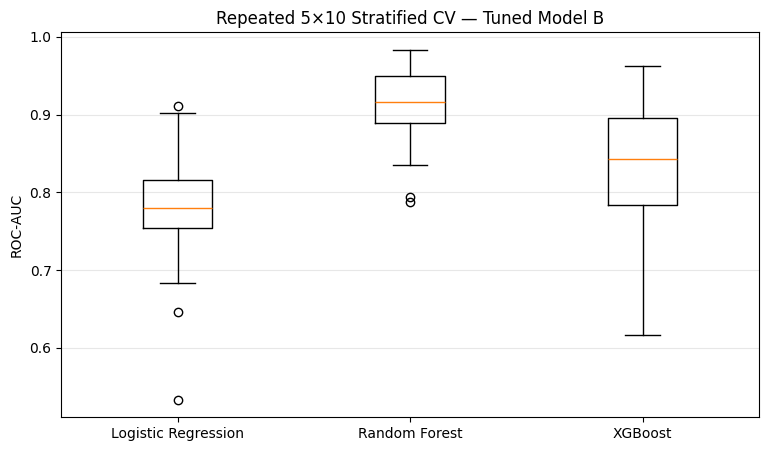

In [ ]:
models_order = [
    "B_LogisticRegression_Tuned",
    "B_RandomForest_Tuned",
    "B_XGBoost_Tuned"
]

data_to_plot = [
    repeated_cv_results_df.loc[
        repeated_cv_results_df["model"] == model,
        "roc_auc"
    ].values
    for model in models_order
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_to_plot,
    labels=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

plt.ylabel("ROC-AUC")
plt.title(
    "Repeated 5×10 Stratified CV — Tuned Model B"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

/tmp/ipykernel_1124/2159839907.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


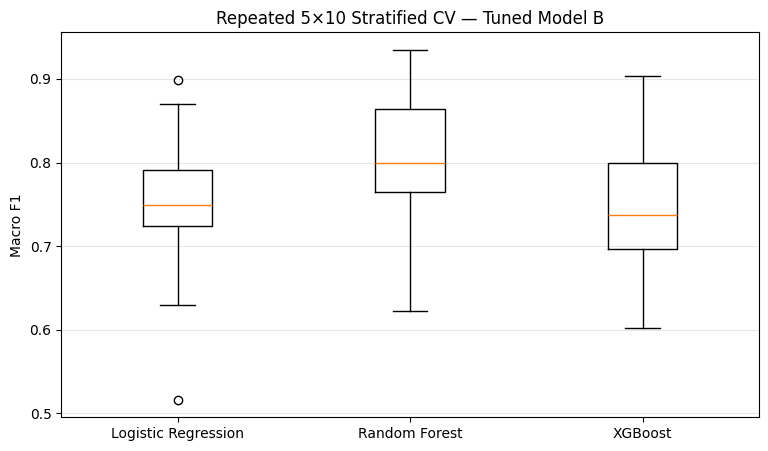

In [ ]:
data_to_plot = [
    repeated_cv_results_df.loc[
        repeated_cv_results_df["model"] == model,
        "macro_f1"
    ].values
    for model in models_order
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    data_to_plot,
    labels=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

plt.ylabel("Macro F1")
plt.title(
    "Repeated 5×10 Stratified CV — Tuned Model B"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [ ]:
STABILITY_DIR = (
    RESULTS_DIR / "repeated_cv"
)

STABILITY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

repeated_cv_results_df.to_csv(
    STABILITY_DIR /
    "repeated_cv_fold_results.csv",
    index=False
)

repeated_cv_summary.to_csv(
    STABILITY_DIR /
    "repeated_cv_summary.csv",
    index=False
)

rf_vs_xgb.to_csv(
    STABILITY_DIR /
    "rf_vs_xgb_paired_fold_differences.csv",
    index=False
)

rf_vs_xgb_summary.to_csv(
    STABILITY_DIR /
    "rf_vs_xgb_summary.csv",
    index=False
)

fold_win_summary.to_csv(
    STABILITY_DIR /
    "algorithm_fold_win_summary.csv",
    index=False
)

print(
    "Repeated-CV stability results saved."
)

Repeated-CV stability results saved.


**SHAP**

In [ ]:
!pip install -q shap
import shap

In [ ]:
selected_model = rf_search.best_estimator_

print(selected_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['analytical_thinking',
                                                   'resilience_flexibility_agility',
                                                   'leadership_social_influence',
                                                   'creative_thinking',
                                                   'motivation_self_awareness',
                                                   'technological_literacy',
                                                   'empathy_active_listening...
           

In [ ]:
selected_preprocessor = (
    selected_model.named_steps["preprocessor"]
)

selected_classifier = (
    selected_model.named_steps["classifier"]
)

print(
    "Classifier:",
    type(selected_classifier)
)

Classifier: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
X_B_train_transformed = (
    selected_preprocessor.transform(
        X_B_train
    )
)

X_B_test_transformed = (
    selected_preprocessor.transform(
        X_B_test
    )
)

print(
    "Transformed train shape:",
    X_B_train_transformed.shape
)

print(
    "Transformed test shape:",
    X_B_test_transformed.shape
)

Transformed train shape: (152, 82)
Transformed test shape: (39, 82)


In [ ]:
transformed_feature_names = (
    selected_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

for feature in transformed_feature_names:
    print(feature)

Number of transformed features: 82
numeric__analytical_thinking
numeric__resilience_flexibility_agility
numeric__leadership_social_influence
numeric__creative_thinking
numeric__motivation_self_awareness
numeric__technological_literacy
numeric__empathy_active_listening
numeric__curiosity_lifelong_learning
numeric__talent_management
numeric__service_orientation
numeric__age
numeric__household_size
numeric__english_communication
numeric__digital_confidence
categorical__gender_Female
categorical__gender_Male
categorical__marital_status_Divorced / Separated
categorical__marital_status_Married
categorical__marital_status_Never married
categorical__marital_status_Prefer not to say
categorical__marital_status_Widowed
categorical__education_level_Bachelor's Degree
categorical__education_level_Certificate / Vocational Training
categorical__education_level_Diploma / HND
categorical__education_level_GCE A-Level
categorical__education_level_GCE O-Level
categorical__education_level_Postgraduate Qual

In [ ]:
if hasattr(
    X_B_train_transformed,
    "toarray"
):
    X_B_train_transformed = (
        X_B_train_transformed.toarray()
    )

if hasattr(
    X_B_test_transformed,
    "toarray"
):
    X_B_test_transformed = (
        X_B_test_transformed.toarray()
    )


X_train_shap = pd.DataFrame(
    X_B_train_transformed,
    columns=transformed_feature_names,
    index=X_B_train.index
)

X_test_shap = pd.DataFrame(
    X_B_test_transformed,
    columns=transformed_feature_names,
    index=X_B_test.index
)

print(X_train_shap.shape)
print(X_test_shap.shape)

display(
    X_train_shap.head()
)

(152, 82)
(39, 82)


,numeric__analytical_thinking,numeric__resilience_flexibility_agility,numeric__leadership_social_influence,numeric__creative_thinking,numeric__motivation_self_awareness,numeric__technological_literacy,numeric__empathy_active_listening,numeric__curiosity_lifelong_learning,numeric__talent_management,numeric__service_orientation,numeric__age,numeric__household_size,numeric__english_communication,numeric__digital_confidence,categorical__gender_Female,categorical__gender_Male,categorical__marital_status_Divorced / Separated,categorical__marital_status_Married,categorical__marital_status_Never married,categorical__marital_status_Prefer not to say,categorical__marital_status_Widowed,categorical__education_level_Bachelor's Degree,categorical__education_level_Certificate / Vocational Training,categorical__education_level_Diploma / HND,categorical__education_level_GCE A-Level,categorical__education_level_GCE O-Level,categorical__education_level_Postgraduate Qualification,categorical__field_of_study_Arts / Humanities / Social Sciences,categorical__field_of_study_Business / Commerce / Management,categorical__field_of_study_Engineering / Technology,categorical__field_of_study_General Education / No specialization,categorical__field_of_study_IT / Computer Science,categorical__field_of_study_Science / Mathematics,categorical__field_of_study_Vocational Trades,categorical__time_since_studies_6-12 months,categorical__time_since_studies_Less than 6 months,categorical__time_since_studies_More than 12 months,categorical__time_since_studies_Not completed yet,categorical__province_Central,categorical__province_Eastern,categorical__province_North Western,categorical__province_Northern,categorical__province_Sabaragamuwa,categorical__province_Southern,categorical__province_Uva,categorical__province_Western,categorical__digital_access_Average,categorical__digital_access_Excellent,categorical__digital_access_Good,categorical__digital_access_Limited access,categorical__digital_access_No access / Very unreliable,categorical__formal_training_No,categorical__formal_training_Yes,categorical__training_type_Apprenticeship / Technical training,categorical__training_type_Certificate course,categorical__training_type_Diploma,categorical__training_type_Higher Diploma,categorical__training_type_NOT_APPLICABLE_NO_FORMAL_TRAINING,categorical__training_type_NVQ,categorical__training_type_Other,categorical__training_type_Professional qualification,categorical__training_field_Agriculture,categorical__training_field_Automobile / Mechanical,categorical__training_field_Beauty / Personal Care,categorical__training_field_Business / Management,categorical__training_field_Construction,categorical__training_field_Healthcare,categorical__training_field_Hospitality / Tourism,categorical__training_field_Information Technology,categorical__training_field_NOT_APPLICABLE_NO_FORMAL_TRAINING,categorical__training_field_Other,categorical__training_duration_3-6 months,categorical__training_duration_6-12 months,categorical__training_duration_Less than 3 months,categorical__training_duration_More than 1 year,categorical__training_duration_NOT_APPLICABLE_NO_FORMAL_TRAINING,categorical__training_relevance_Highly relevant,categorical__training_relevance_Moderately relevant,categorical__training_relevance_NOT_APPLICABLE_NO_FORMAL_TRAINING,categorical__training_relevance_Not relevant,categorical__training_relevance_Slightly relevant,categorical__training_relevance_Very relevant
136,-1.340905,-1.321817,-1.793228,-2.255758,-1.522636,-0.912515,-1.194331,-0.444137,-0.213519,-1.894424,-0.662522,1.917318,-2.117024,0.201882,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
75,-1.340905,-1.321817,-1.793228,-2.255758,-1.522636,-0.912515,-1.194331,-0.444137,-0.213519,-1.894424,-0.662522,

In [ ]:
explainer = shap.TreeExplainer(
    selected_classifier
)

shap_values_raw = explainer(
    X_test_shap
)

print(
    "SHAP values shape:",
    shap_values_raw.values.shape
)

SHAP values shape: (39, 82, 2)


In [ ]:
if shap_values_raw.values.ndim == 3:

    shap_values_employed = (
        shap_values_raw.values[:, :, 1]
    )

    base_values_employed = (
        shap_values_raw.base_values[:, 1]
    )

else:

    shap_values_employed = (
        shap_values_raw.values
    )

    base_values_employed = (
        shap_values_raw.base_values
    )


print(
    "Class-1 SHAP shape:",
    shap_values_employed.shape
)

Class-1 SHAP shape: (39, 82)


Global SHAP importance

In [ ]:
global_shap_importance = pd.DataFrame({
    "feature":
        transformed_feature_names,

    "mean_abs_shap":
        np.abs(
            shap_values_employed
        ).mean(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    global_shap_importance.head(25)
)

,feature,mean_abs_shap
0,categorical__province_Uva,0.038988
1,categorical__field_of_study_Business / Commerc...,0.026980
2,numeric__leadership_social_influence,0.024557
3,categorical__gender_Female,0.022270
4,categorical__gender_Male,0.020522
5,categorical__field_of_study_General Education ...,0.018717
6,categorical__education_level_Diploma / HND,0.014330
7,numeric__digital_confidence,0.013123
8,numeric__talent_management,0.012733
9,categorical__province_Western,0.011802


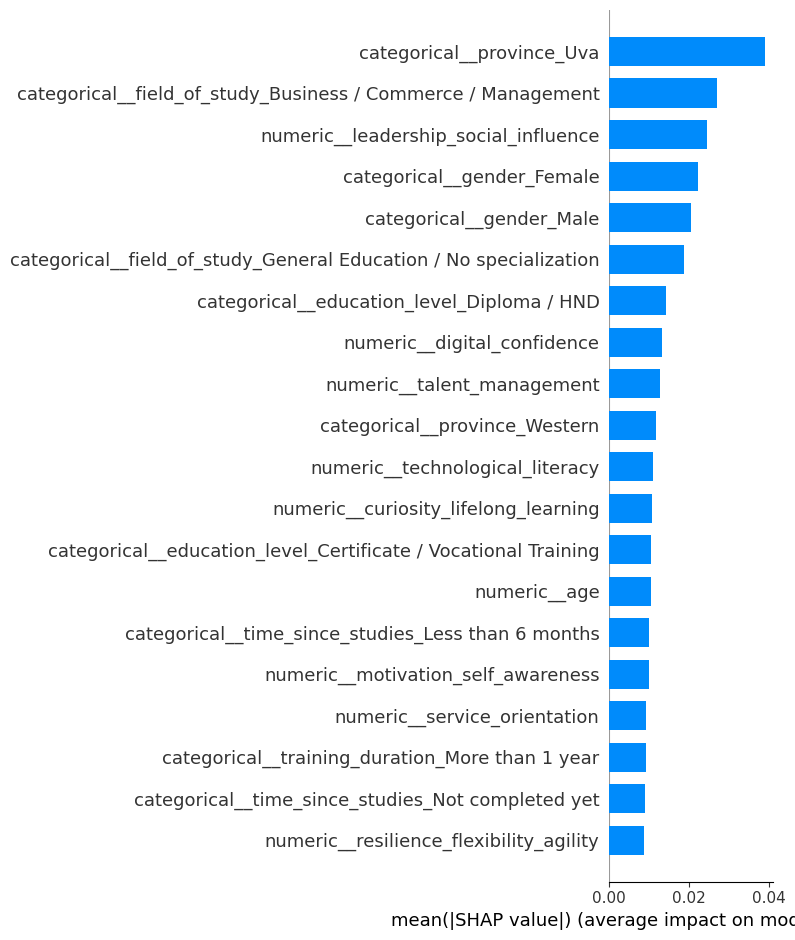

In [ ]:
shap.summary_plot(
    shap_values_employed,
    X_test_shap,
    plot_type="bar",
    max_display=20
)

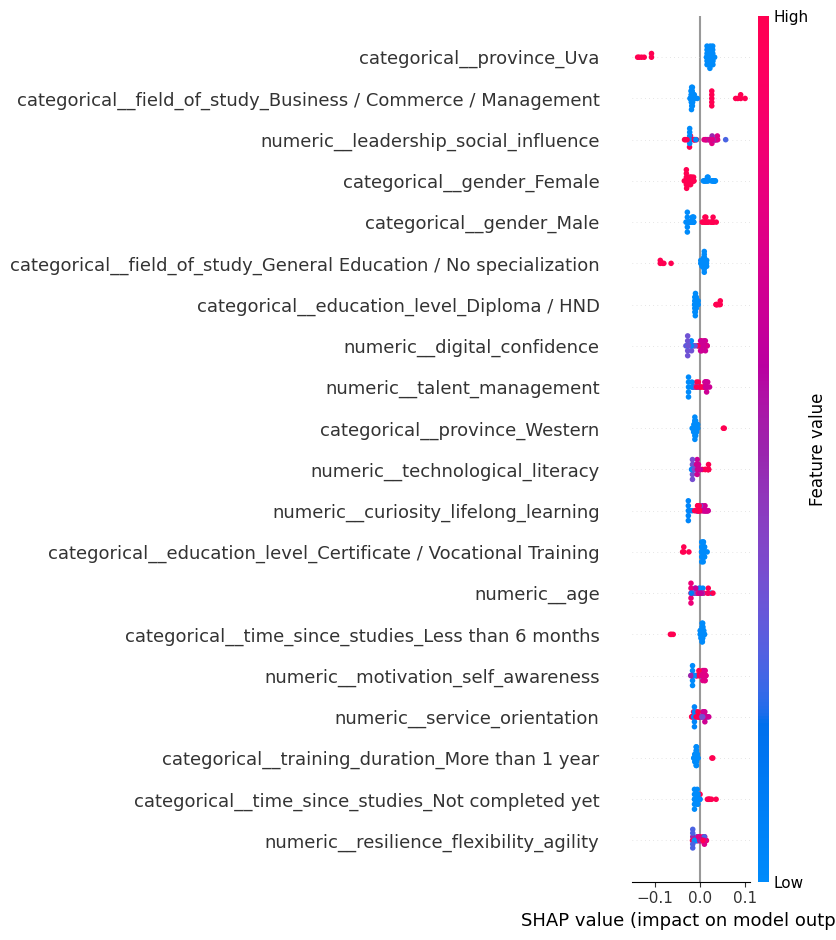

In [ ]:
shap.summary_plot(
    shap_values_employed,
    X_test_shap,
    max_display=20
)

In [ ]:
def get_original_feature_name(
    transformed_name
):

    # Numeric features
    if transformed_name.startswith(
        "numeric__"
    ):
        return transformed_name.replace(
            "numeric__",
            ""
        )

    # Categorical features
    if transformed_name.startswith(
        "categorical__"
    ):

        clean_name = transformed_name.replace(
            "categorical__",
            ""
        )

        # Match against known categorical
        # feature names.
        for feature in sorted(
            MODEL_B_CATEGORICAL_FEATURES,
            key=len,
            reverse=True
        ):

            prefix = feature + "_"

            if clean_name.startswith(prefix):
                return feature

        return clean_name

    return transformed_name

In [ ]:
global_shap_importance[
    "original_feature"
] = (
    global_shap_importance["feature"]
    .apply(
        get_original_feature_name
    )
)

display(
    global_shap_importance.head(30)
)

,feature,mean_abs_shap,original_feature
0,categorical__province_Uva,0.038988,province
1,categorical__field_of_study_Business / Commerc...,0.026980,field_of_study
2,numeric__leadership_social_influence,0.024557,leadership_social_influence
3,categorical__gender_Female,0.022270,gender
4,categorical__gender_Male,0.020522,gender
5,categorical__field_of_study_General Education ...,0.018717,field_of_study
6,categorical__education_level_Diploma / HND,0.014330,education_level
7,numeric__digital_confidence,0.013123,digital_confidence
8,numeric__talent_management,0.012733,talent_management
9,categorical__province_Western,0.011802,province


In [ ]:
original_feature_importance = (
    global_shap_importance
    .groupby(
        "original_feature",
        as_index=False
    )["mean_abs_shap"]
    .sum()
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    original_feature_importance
)

,original_feature,mean_abs_shap
0,province,0.072113
1,field_of_study,0.062715
2,gender,0.042792
3,education_level,0.036170
4,training_field,0.027256
5,time_since_studies,0.026076
6,leadership_social_influence,0.024557
7,training_duration,0.021718
8,training_type,0.021606
9,digital_access,0.021345


In [ ]:
print(
    "Expected original features:",
    len(MODEL_B_FEATURES)
)

print(
    "SHAP aggregated features:",
    len(original_feature_importance)
)

missing_from_shap = set(
    MODEL_B_FEATURES
) - set(
    original_feature_importance[
        "original_feature"
    ]
)

print(
    "\nMissing original features:",
    missing_from_shap
)

Expected original features: 26
SHAP aggregated features: 26

Missing original features: set()


In [ ]:
original_feature_importance[
    "feature_group"
] = np.where(
    original_feature_importance[
        "original_feature"
    ].isin(MODEL_A_FEATURES),
    "Skill",
    "Additional Model B factor"
)

display(
    original_feature_importance
)

,original_feature,mean_abs_shap,feature_group
0,province,0.072113,Additional Model B factor
1,field_of_study,0.062715,Additional Model B factor
2,gender,0.042792,Additional Model B factor
3,education_level,0.036170,Additional Model B factor
4,training_field,0.027256,Additional Model B factor
5,time_since_studies,0.026076,Additional Model B factor
6,leadership_social_influence,0.024557,Skill
7,training_duration,0.021718,Additional Model B factor
8,training_type,0.021606,Additional Model B factor
9,digital_access,0.021345,Additional Model B factor


In [ ]:
group_importance = (
    original_feature_importance
    .groupby(
        "feature_group",
        as_index=False
    )["mean_abs_shap"]
    .sum()
)

group_importance[
    "importance_percentage"
] = (
    group_importance["mean_abs_shap"]
    /
    group_importance[
        "mean_abs_shap"
    ].sum()
    * 100
)

display(
    group_importance.round(2)
)

,feature_group,mean_abs_shap,importance_percentage
0,Additional Model B factor,0.40,78.67
1,Skill,0.11,21.33


In [ ]:
local_position = 0

original_row_index = (
    X_test_shap.index[
        local_position
    ]
)

print(
    "Original dataframe index:",
    original_row_index
)

print(
    "True outcome:",
    y_test.loc[
        original_row_index
    ]
)

display(
    X_B.loc[
        [original_row_index]
    ]
)

Original dataframe index: 153
True outcome: 1


,analytical_thinking,resilience_flexibility_agility,leadership_social_influence,creative_thinking,motivation_self_awareness,technological_literacy,empathy_active_listening,curiosity_lifelong_learning,talent_management,service_orientation,age,gender,marital_status,household_size,education_level,field_of_study,time_since_studies,province,digital_access,english_communication,digital_confidence,formal_training,training_type,training_field,training_duration,training_relevance
153,3.0,3.0,5.0,5.0,4.0,1.0,5.0,5.0,5.0,4.0,24,Male,Never married,6,GCE O-Level,Vocational Trades,Not completed yet,Central,Excellent,3,4,No,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING,NOT_APPLICABLE_NO_FORMAL_TRAINING


In [ ]:
respondent_original = (
    X_B.loc[
        [original_row_index]
    ]
)

predicted_probability = (
    selected_model
    .predict_proba(
        respondent_original
    )[0, 1]
)

predicted_class = (
    selected_model
    .predict(
        respondent_original
    )[0]
)

print(
    "Predicted class:",
    predicted_class
)

print(
    "Predicted employment probability:",
    round(
        predicted_probability,
        4
    )
)

Predicted class: 0
Predicted employment probability: 0.4638


In [ ]:
local_explanation = shap.Explanation(
    values=
        shap_values_employed[
            local_position
        ],

    base_values=
        base_values_employed[
            local_position
        ],

    data=
        X_test_shap.iloc[
            local_position
        ].values,

    feature_names=
        transformed_feature_names
)

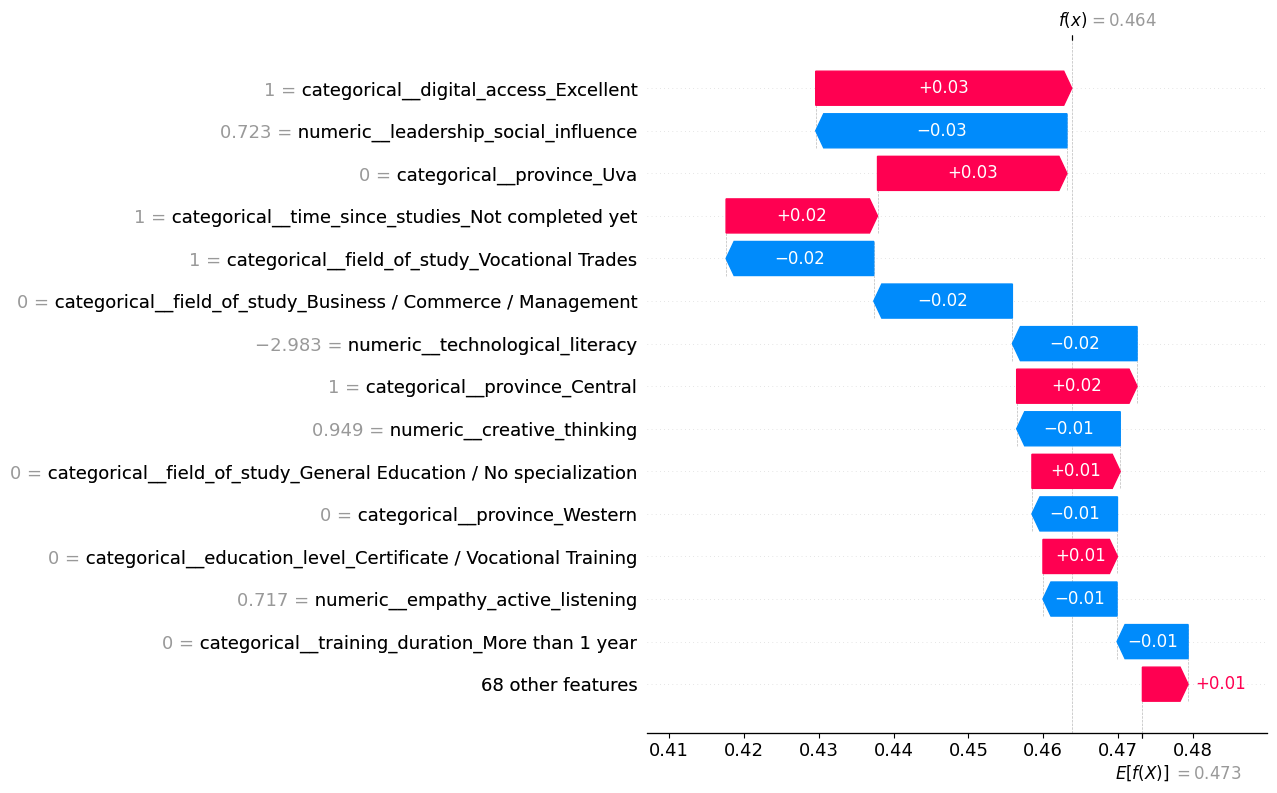

In [ ]:
shap.plots.waterfall(
    local_explanation,
    max_display=15
)

In [ ]:
SKILL_FEATURES = MODEL_A_FEATURES.copy()

IMMUTABLE_FEATURES = [
    "age",
    "gender",
    "marital_status"
]

CONTEXTUAL_NON_ACTIONABLE_FEATURES = [
    "household_size",
    "province",
    "time_since_studies"
]

EDUCATION_BACKGROUND_FEATURES = [
    "education_level",
    "field_of_study"
]

TRAINING_FEATURES = [
    "formal_training",
    "training_type",
    "training_field",
    "training_duration",
    "training_relevance"
]

CURRENT_CAPABILITY_FEATURES = [
    "digital_access",
    "english_communication",
    "digital_confidence"
]

In [ ]:
def assign_interpretation_group(feature):

    if feature in SKILL_FEATURES:
        return "Skill"

    if feature in IMMUTABLE_FEATURES:
        return "Immutable demographic"

    if feature in CONTEXTUAL_NON_ACTIONABLE_FEATURES:
        return "Contextual / non-actionable"

    if feature in EDUCATION_BACKGROUND_FEATURES:
        return "Education background"

    if feature in TRAINING_FEATURES:
        return "Training characteristic"

    if feature in CURRENT_CAPABILITY_FEATURES:
        return "Current capability / access"

    return "Other"


original_feature_importance[
    "interpretation_group"
] = (
    original_feature_importance[
        "original_feature"
    ].apply(
        assign_interpretation_group
    )
)

display(
    original_feature_importance
)

,original_feature,mean_abs_shap,feature_group,interpretation_group
0,province,0.072113,Additional Model B factor,Contextual / non-actionable
1,field_of_study,0.062715,Additional Model B factor,Education background
2,gender,0.042792,Additional Model B factor,Immutable demographic
3,education_level,0.036170,Additional Model B factor,Education background
4,training_field,0.027256,Additional Model B factor,Training characteristic
5,time_since_studies,0.026076,Additional Model B factor,Contextual / non-actionable
6,leadership_social_influence,0.024557,Skill,Skill
7,training_duration,0.021718,Additional Model B factor,Training characteristic
8,training_type,0.021606,Additional Model B factor,Training characteristic
9,digital_access,0.021345,Additional Model B factor,Current capability / access


In [ ]:
interpretation_group_summary = (
    original_feature_importance
    .groupby(
        "interpretation_group",
        as_index=False
    )["mean_abs_shap"]
    .sum()
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

interpretation_group_summary[
    "percentage"
] = (
    interpretation_group_summary[
        "mean_abs_shap"
    ]
    /
    interpretation_group_summary[
        "mean_abs_shap"
    ].sum()
    * 100
)

display(
    interpretation_group_summary.round(2)
)

,interpretation_group,mean_abs_shap,percentage
4,Skill,0.11,21.33
0,Contextual / non-actionable,0.10,20.70
2,Education background,0.10,19.58
5,Training characteristic,0.09,17.09
3,Immutable demographic,0.06,12.83
1,Current capability / access,0.04,8.47


In [ ]:
SHAP_DIR = (
    RESULTS_DIR / "shap"
)

SHAP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

global_shap_importance.to_csv(
    SHAP_DIR /
    "transformed_feature_shap_importance.csv",
    index=False
)

original_feature_importance.to_csv(
    SHAP_DIR /
    "original_feature_shap_importance.csv",
    index=False
)

group_importance.to_csv(
    SHAP_DIR /
    "skill_vs_additional_shap_importance.csv",
    index=False
)

interpretation_group_summary.to_csv(
    SHAP_DIR /
    "shap_interpretation_group_summary.csv",
    index=False
)

print(
    "SHAP results saved successfully."
)

SHAP results saved successfully.


In [ ]:
OPTIMIZED_THRESHOLD = 0.52

print("Locked deployment threshold:", OPTIMIZED_THRESHOLD)

Locked deployment threshold: 0.52


In [ ]:
FINAL_MODEL = rf_search.best_estimator_

print("Final selected development model:")
print(type(FINAL_MODEL))

classifier = FINAL_MODEL.named_steps["classifier"]

print("\nRandom Forest parameters:")
print("n_estimators:", classifier.n_estimators)
print("max_depth:", classifier.max_depth)
print("max_features:", classifier.max_features)
print("min_samples_leaf:", classifier.min_samples_leaf)
print("min_samples_split:", classifier.min_samples_split)
print("class_weight:", classifier.class_weight)
print("random_state:", classifier.random_state)

Final selected development model:
<class 'sklearn.pipeline.Pipeline'>

Random Forest parameters:
n_estimators: 576
max_depth: 10
max_features: log2
min_samples_leaf: 1
min_samples_split: 2
class_weight: None
random_state: 42


In [ ]:
MODEL_B_FEATURES = [
    # Skills
    "analytical_thinking",
    "resilience_flexibility_agility",
    "leadership_social_influence",
    "creative_thinking",
    "motivation_self_awareness",
    "technological_literacy",
    "empathy_active_listening",
    "curiosity_lifelong_learning",
    "talent_management",
    "service_orientation",

    # Demographic
    "age",
    "gender",
    "marital_status",
    "household_size",

    # Education
    "education_level",
    "field_of_study",
    "time_since_studies",

    # Structural/contextual
    "province",
    "digital_access",
    "english_communication",
    "digital_confidence",

    # Training
    "formal_training",
    "training_type",
    "training_field",
    "training_duration",
    "training_relevance",
]

print("Required deployment inputs:", len(MODEL_B_FEATURES))

for i, feature in enumerate(MODEL_B_FEATURES, start=1):
    print(i, feature)

Required deployment inputs: 26
1 analytical_thinking
2 resilience_flexibility_agility
3 leadership_social_influence
4 creative_thinking
5 motivation_self_awareness
6 technological_literacy
7 empathy_active_listening
8 curiosity_lifelong_learning
9 talent_management
10 service_orientation
11 age
12 gender
13 marital_status
14 household_size
15 education_level
16 field_of_study
17 time_since_studies
18 province
19 digital_access
20 english_communication
21 digital_confidence
22 formal_training
23 training_type
24 training_field
25 training_duration
26 training_relevance


In [ ]:
SKILL_FEATURES = [
    "analytical_thinking",
    "resilience_flexibility_agility",
    "leadership_social_influence",
    "creative_thinking",
    "motivation_self_awareness",
    "technological_literacy",
    "empathy_active_listening",
    "curiosity_lifelong_learning",
    "talent_management",
    "service_orientation",
]

print("Skill features:", len(SKILL_FEATURES))

Skill features: 10


In [ ]:
def predict_employability(model, input_df, threshold=0.52):

    probability = float(
        model.predict_proba(
            input_df[MODEL_B_FEATURES]
        )[0, 1]
    )

    predicted_class = int(
        probability >= threshold
    )

    return {
        "employment_probability": probability,
        "predicted_class": predicted_class,
        "threshold": threshold
    }

In [ ]:
sample_input = df[MODEL_B_FEATURES].iloc[[0]].copy()

sample_result = predict_employability(
    FINAL_MODEL,
    sample_input,
    OPTIMIZED_THRESHOLD
)

sample_result

{'employment_probability': 0.8324789740117775,
 'predicted_class': 1,
 'threshold': 0.52}

In [ ]:
direct_probability = FINAL_MODEL.predict_proba(
    sample_input
)[0, 1]

helper_probability = sample_result[
    "employment_probability"
]

print(
    "Direct probability:",
    direct_probability
)

print(
    "Helper probability:",
    helper_probability
)

print(
    "Difference:",
    abs(
        direct_probability
        - helper_probability
    )
)

Direct probability: 0.8324789740117775
Helper probability: 0.8324789740117775
Difference: 0.0


In [ ]:
import joblib
from pathlib import Path

DEPLOYMENT_DIR = Path(
    "/content/deployment_artifacts"
)

DEPLOYMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_OUTPUT_PATH = (
    DEPLOYMENT_DIR
    / "employability_model_b_random_forest.pkl"
)

joblib.dump(
    FINAL_MODEL,
    MODEL_OUTPUT_PATH
)

print("Model saved:")
print(MODEL_OUTPUT_PATH)

Model saved:
/content/deployment_artifacts/employability_model_b_random_forest.pkl


In [ ]:
import json

deployment_metadata = {

    "model_name":
        "Model B Tuned Random Forest",

    "model_type":
        "RandomForestClassifier",

    "target":
        "employment_outcome",

    "class_definition": {
        "0":
            "Active unemployed recent-search",
        "1":
            "Employed"
    },

    "decision_threshold":
        OPTIMIZED_THRESHOLD,

    "threshold_selection":
        "Maximized balanced accuracy using training-only 5-fold out-of-fold predictions",

    "random_state":
        42,

    "feature_count":
        len(MODEL_B_FEATURES),

    "features":
        MODEL_B_FEATURES,

    "skill_features":
        SKILL_FEATURES,

    "model_version":
        "preliminary_real_data_v1"
}


METADATA_PATH = (
    DEPLOYMENT_DIR
    / "employability_model_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        deployment_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )


print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
/content/deployment_artifacts/employability_model_metadata.json


In [ ]:
categorical_features = [
    "gender",
    "marital_status",
    "education_level",
    "field_of_study",
    "time_since_studies",
    "province",
    "digital_access",
    "formal_training",
    "training_type",
    "training_field",
    "training_duration",
    "training_relevance",
]

canonical_categories = {}

for feature in categorical_features:

    canonical_categories[feature] = sorted(
        df[feature]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


CATEGORY_PATH = (
    DEPLOYMENT_DIR
    / "canonical_categories.json"
)

with open(
    CATEGORY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        canonical_categories,
        f,
        indent=4,
        ensure_ascii=False
    )


print("Canonical categories saved:")
print(CATEGORY_PATH)

Canonical categories saved:
/content/deployment_artifacts/canonical_categories.json


In [ ]:
for feature, values in canonical_categories.items():

    print("\n" + "=" * 60)
    print(feature)

    for value in values:
        print("-", value)


gender
- Female
- Male

marital_status
- Divorced / Separated
- Married
- Never married
- Prefer not to say
- Widowed

education_level
- Bachelor's Degree
- Certificate / Vocational Training
- Diploma / HND
- GCE A-Level
- GCE O-Level
- Postgraduate Qualification

field_of_study
- Arts / Humanities / Social Sciences
- Business / Commerce / Management
- Engineering / Technology
- General Education / No specialization
- IT / Computer Science
- Science / Mathematics
- Vocational Trades

time_since_studies
- 6-12 months
- Less than 6 months
- More than 12 months
- Not completed yet

province
- Central
- Eastern
- North Western
- Northern
- Sabaragamuwa
- Southern
- Uva
- Western

digital_access
- Average
- Excellent
- Good
- Limited access
- No access / Very unreliable

formal_training
- No
- Yes

training_type
- Apprenticeship / Technical training
- Certificate course
- Diploma
- Higher Diploma
- NOT_APPLICABLE_NO_FORMAL_TRAINING
- NVQ
- Other
- Professional qualification

training_field

In [ ]:
SHAP_OUTPUT_DIR = (
    DEPLOYMENT_DIR / "shap_reference"
)

SHAP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

original_feature_importance.to_csv(
    SHAP_OUTPUT_DIR
    / "global_original_feature_shap_importance.csv",
    index=False
)

interpretation_group_summary.to_csv(
    SHAP_OUTPUT_DIR
    / "global_shap_group_summary.csv",
    index=False
)

print("Global SHAP reference outputs saved.")

Global SHAP reference outputs saved.


In [ ]:
evaluation_summary = {

    "selected_model":
        "B_RandomForest_Tuned",

    "selection_basis":
        "Repeated 5x10 stratified cross-validation",

    "development_sample_size":
        len(df),

    "decision_threshold":
        OPTIMIZED_THRESHOLD,

    "repeated_cv": {
        "roc_auc_mean":
            0.9132,

        "balanced_accuracy_mean":
            0.8087,

        "macro_f1_mean":
            0.8073
    },

    "limitations": [
        "Current model is trained on a preliminary real-data sample.",
        "Performance estimates must be repeated after final data collection.",
        "SHAP values represent model explanations, not causal effects.",
        "Counterfactual skill recommendations were evaluated experimentally but were not adopted as a deployed recommendation mechanism."
    ]
}


EVALUATION_PATH = (
    DEPLOYMENT_DIR
    / "model_evaluation_summary.json"
)

with open(
    EVALUATION_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        evaluation_summary,
        f,
        indent=4
    )


print("Evaluation summary saved.")

Evaluation summary saved.


In [ ]:
import sys
import sklearn
import pandas
import numpy
import joblib

environment_info = {
    "python":
        sys.version,

    "scikit_learn":
        sklearn.__version__,

    "pandas":
        pandas.__version__,

    "numpy":
        numpy.__version__,

    "joblib":
        joblib.__version__,
}


ENVIRONMENT_PATH = (
    DEPLOYMENT_DIR
    / "environment_versions.json"
)

with open(
    ENVIRONMENT_PATH,
    "w"
) as f:

    json.dump(
        environment_info,
        f,
        indent=4
    )


display(
    pd.DataFrame(
        environment_info.items(),
        columns=[
            "package",
            "version"
        ]
    )
)

,package,version
0,python,"3.13.15 (main, Aug 6 2026, 11:06:23) [GCC 11...."
1,scikit_learn,1.6.1
2,pandas,2.2.3
3,numpy,2.1.3
4,joblib,1.5.3


In [ ]:
deployment_model = joblib.load(
    MODEL_OUTPUT_PATH
)

deployment_probability = float(
    deployment_model
    .predict_proba(
        sample_input[
            MODEL_B_FEATURES
        ]
    )[0, 1]
)

original_probability = float(
    FINAL_MODEL
    .predict_proba(
        sample_input[
            MODEL_B_FEATURES
        ]
    )[0, 1]
)


print(
    "Original model probability:",
    original_probability
)

print(
    "Reloaded model probability:",
    deployment_probability
)

print(
    "Absolute difference:",
    abs(
        original_probability
        - deployment_probability
    )
)

Original model probability: 0.8324789740117775
Reloaded model probability: 0.8324789740117775
Absolute difference: 0.0


In [ ]:
deployment_class = int(
    deployment_probability
    >= OPTIMIZED_THRESHOLD
)

print(
    "Probability:",
    round(
        deployment_probability,
        4
    )
)

print(
    "Threshold:",
    OPTIMIZED_THRESHOLD
)

print(
    "Predicted class:",
    deployment_class
)

Probability: 0.8325
Threshold: 0.52
Predicted class: 1
